# Задачи исследования

### Осмотр данных

### Обработка данных

### Ответы на вопросы

* Каковы типичные параметры продаваемых квартир (например, площадь, цена)? Укажите наиболее важные характеристики и постройте графики. Сколько обычно длится процесс продажи?

* Уберите квартиры с очень высокой ценой и другими необычными параметрами. Опишите, какие особенности обнаружили.

* Какие факторы больше всего влияют на стоимость квартиры? Отдельно изучите, зависит ли цена квадратного метра от числа комнат, этажа (первого или последнего), удалённости от центра и даты размещения: дня недели, месяца и года.

* Что можно сказать о цене квадратного метра в пригородах? Выберите 10 населённых пунктов с наибольшим числом объявлений. Эти данные можно отличить по имени в столбце 'locality_name'.

* Выделите сегменты типичных квартир в центре (по удалённости, числу комнат и площади) и вне центра. Границы определите самостоятельно. Выберите достаточно крупные сегменты с не менее 1000 объявлений. Сравните корреляцию основных факторов с ценой по всем предложениям и объявлениям в вашей выборке.

* Подберите наиболее характерные параметры для апартаментов, студий и квартир свободной планировки. Влияют ли они на цену? Сравните со схожими параметрами квартир типовой планировки.

### Результаты исследования

### Общие выводы

### Рекомендации

# Описание данных
* airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
* balcony — число балконов
* ceiling_height — высота потолков (м)
* cityCenters_nearest — расстояние до центра города (м)
* days_exposition — сколько дней было размещено объявление (от публикации до снятия)
* first_day_exposition — дата публикации
* floor — этаж
* floors_total — всего этажей в доме
* is_apartment — апартаменты (булев тип)
* kitchen_area — площадь кухни (м²)
* last_price — цена на момент снятия с публикации
* living_area — жилая площадь (м²)
* locality_name — название населённого пункта
* open_plan — свободная планировка (булев тип)
* parks_around3000 — число парков в радиусе 3 км
* parks_nearest — расстояние до ближайшего парка (м)
* ponds_around3000 — число водоёмов в радиусе 3 км
* ponds_nearest — расстояние до ближайшего водоёма (м)
* rooms — число комнат
* studio — квартира-студия (булев тип)
* total_area — площадь квартиры в квадратных метрах (м²)
* total_images — число фотографий квартиры в объявлении

# Знакомство с данными

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
#%matplotlib inline


In [2]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep="\t")

In [3]:
pd.set_option('display.max_columns', None)
data.head(10)


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [4]:
data.tail(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
23689,13,3550000.0,35.30,2018-02-28T00:00:00,1,2.86,15.0,16.3,4,NaN,False,False,9.10,2.0,Санкт-Петербург,17284.0,16081.0,1.0,353.0,2.0,652.0,29.0
23690,3,5500000.0,52.00,2018-07-19T00:00:00,2,NaN,5.0,31.0,2,NaN,False,False,6.00,NaN,Санкт-Петербург,20151.0,6263.0,1.0,300.0,0.0,NaN,15.0
23691,11,9470000.0,72.90,2016-10-13T00:00:00,2,2.75,25.0,40.3,7,NaN,False,False,10.60,1.0,Санкт-Петербург,19424.0,4489.0,0.0,NaN,1.0,806.0,519.0
23692,2,1350000.0,30.00,2017-07-07T00:00:00,1,NaN,5.0,17.5,4,NaN,False,False,6.00,NaN,Тихвин,NaN,NaN,NaN,NaN,NaN,NaN,413.0
23693,9,4600000.0,62.40,2016-08-05T00:00:00,3,2.60,9.0,40.0,8,NaN,False,False,8.00,0.0,Петергоф,45602.0,34104.0,1.0,352.0,1.0,675.0,239.0
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,False,False,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,False,False,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,False,False,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,False,False,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0
23698,4,1350000.0,32.30,2017-07-21T00:00:00,1,2.50,5.0,12.3,1,NaN,False,False,9.00,NaN,поселок Новый Учхоз,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

- *Также визуализируем исходные данные для более полной картины*

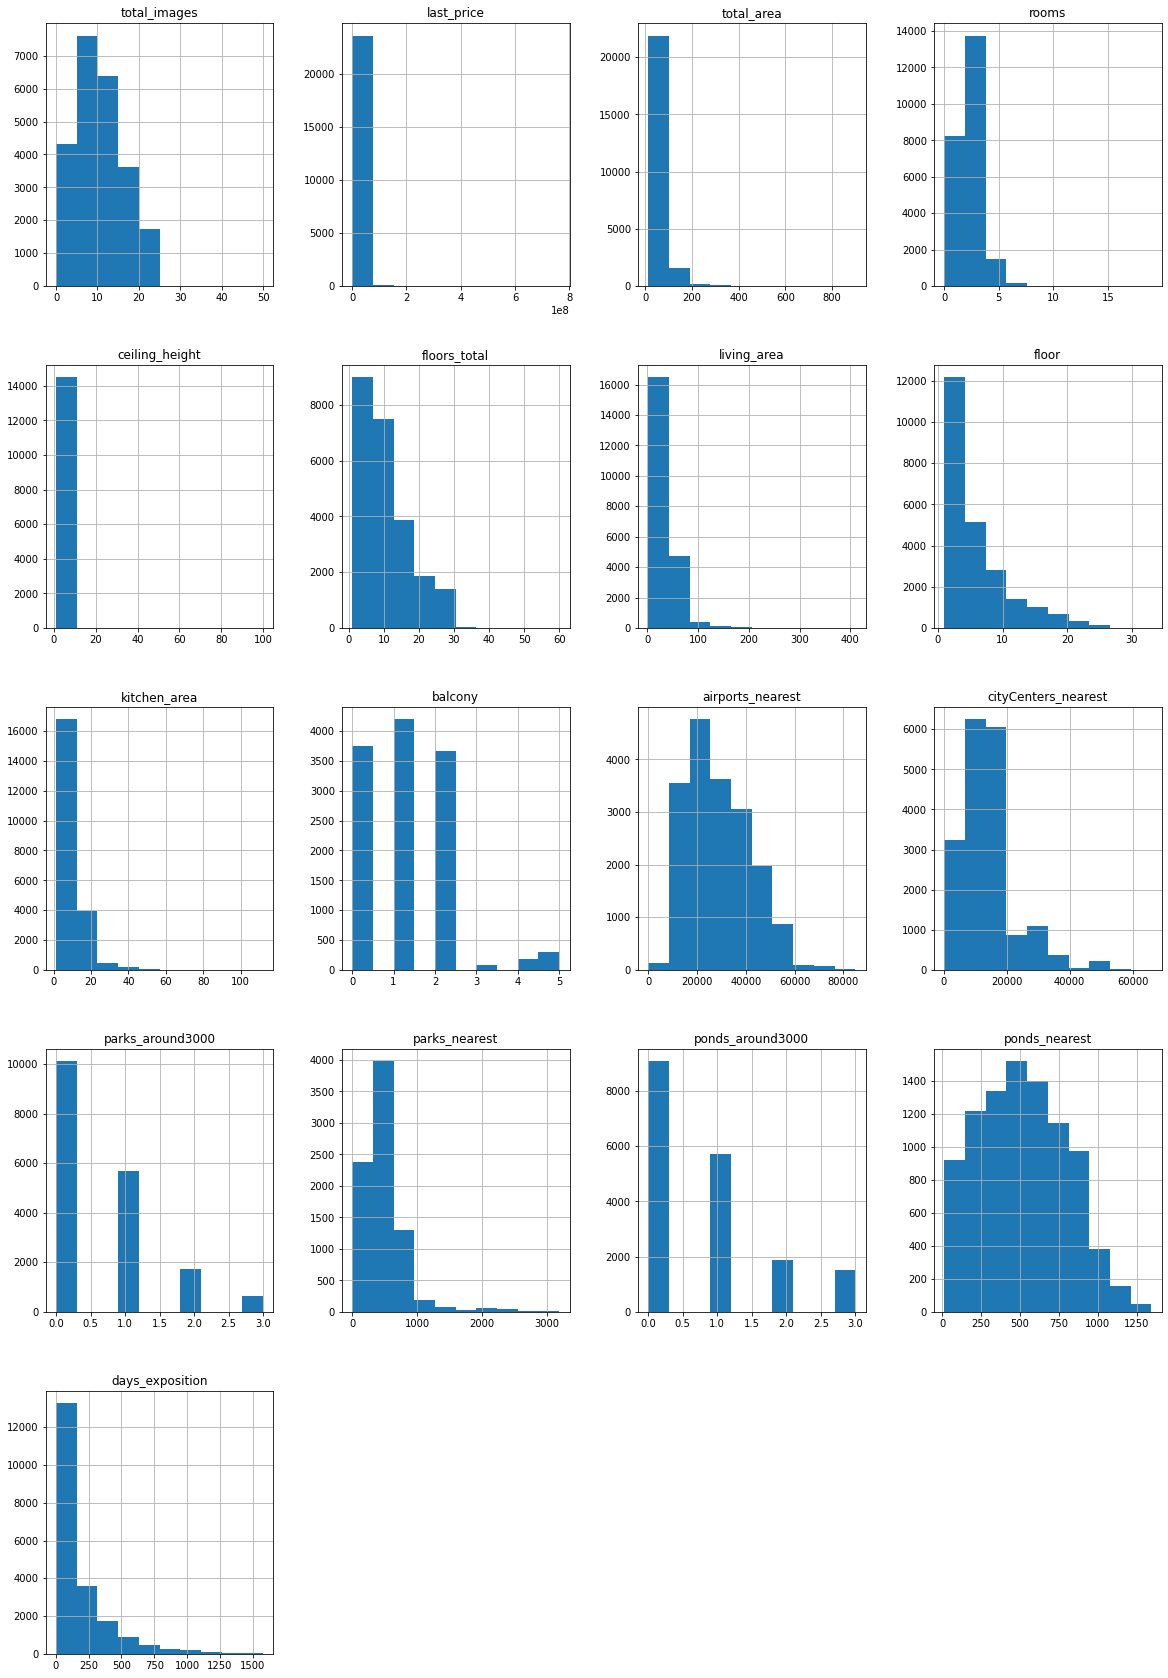

In [6]:
data.hist(figsize=(20, 30));

# Вывод

_**Обнаружено следующее:**_

* first_day_exposition - object - должен быть тип datetime
* ceiling_height - нулевые значения
* floors_total - должен быть тип int, т.к. количество этажей - целое значение + нулевые значения
* is_apartment - должен быть тип bool + нулевые значения
* living_area - нулевые значения
* kitchen_area - нулевые значения
* balcony - нулевые значения
* locality_name - нулевые значения
* airports_nearest - нулевые значения
* cityCenters_nearest - нулевые значения
* parks_around3000 - тип должен быть int + нулевые значения
* parks_nearest - нулевые значения
* ponds_around3000 - тип должен быть int + нулевые значения
* ponds_nearest - нулевые значения
* days_exposition - тип должен быть int + нулевые значения

*Таблица dupl1 добавлена уже после предобработки, чтобы в самом конце более точно идентифицировать дубликаты (в конце предобработки сравним её с таблицей dupl2)*

*Для идентификации дубликатов возьмем совпадения по нескольким столбцам - по тем в которых были все значения изначально и особенно в которых маловероятны совпадения: 1) first_day_exposition (++ его почти не меняли и много разных дат), 2) last_price(++здесь должно быть мало повторении), 3) total_area 4) total_images (вообще не меняли) - этого ВПОЛНЕ достаточно*

In [7]:
dupl1 = data[data[['total_images', 'last_price','first_day_exposition','total_area']].duplicated(keep=False)]
dupl1.sort_values(by='total_images')
print('ТАБЛИЦА dupl1 :')
display(dupl1.sort_values(by='first_day_exposition'))

ТАБЛИЦА dupl1 :


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
19052,3,4370000.0,38.00,2016-06-23T00:00:00,1,NaN,9.0,19.5,1,NaN,False,False,NaN,NaN,Санкт-Петербург,27103.0,7640.0,1.0,624.0,0.0,NaN,620.0
19325,3,4370000.0,38.00,2016-06-23T00:00:00,1,NaN,9.0,NaN,2,NaN,False,False,NaN,NaN,Санкт-Петербург,27103.0,7640.0,1.0,624.0,0.0,NaN,620.0
9661,1,2533531.0,42.50,2016-09-08T00:00:00,1,2.56,18.0,19.8,7,False,False,False,NaN,NaN,Никольское,NaN,NaN,NaN,NaN,NaN,NaN,627.0
18425,1,2533531.0,42.50,2016-09-08T00:00:00,1,2.56,18.0,20.0,10,False,False,False,NaN,NaN,Никольское,NaN,NaN,NaN,NaN,NaN,NaN,627.0
10099,10,4400000.0,44.00,2017-11-22T00:00:00,1,NaN,17.0,17.0,14,NaN,False,False,13.0,2.0,Санкт-Петербург,42901.0,9267.0,0.0,NaN,0.0,NaN,71.0
21142,10,4400000.0,44.00,2017-11-22T00:00:00,2,NaN,9.0,27.0,8,NaN,False,False,6.0,1.0,Санкт-Петербург,49917.0,16755.0,1.0,235.0,0.0,NaN,72.0
14739,10,5142565.0,54.65,2018-10-01T00:00:00,2,NaN,5.0,26.0,3,NaN,False,False,NaN,NaN,Санкт-Петербург,47303.0,25866.0,1.0,251.0,1.0,350.0,145.0
18624,10,5142565.0,54.65,2018-10-01T00:00:00,2,NaN,5.0,26.0,5,NaN,False,False,NaN,NaN,Санкт-Петербург,47303.0,25866.0,1.0,251.0,1.0,350.0,145.0


Пары дубликатов:

(индексы 19045 и 19318) отличаются только этажом (наверно указан был неправильно) - удалить 19318

(индексы 9658 и 18418) отличаются этажом, а площадь почти одинаковая 19,8 и 20 - удалить 18418

(индексы 10096 и 21135) много отличий будем считать, что это разные квартиры

(индексы 14736 и 18617) отличаются только этажом (наверно указан был неправильно) - удалить 18624

Пока отложим. Вернемся к этому позже.

# Предобработка данных

_**Данный этап работы с данными будет состоять из 3 частей:**_

* **пропущенные значения в столбцах:**
*Там, где это возможно, пропущенные значения будут заполнены. Например, если продавец не указал число балконов, то, скорее всего, в его квартире их нет. Такие пропуски можно заменить на число 0. Если логичную замену предложить невозможно, то оставляем пропуски. Пропущенные значения — тоже важный сигнал, который нужно учитывать Причины, которые могли привести к пропускам в данных могут быть как технологическими, так и вызванны человеческим фактором. *

* **Типы данных в каждом столбце:**
*В нескольких столбцах необходимо изменить тип данных. 

* **Уникальные значения в столбце с названиями:**
*Нужно устранить неявные дубликаты. Например, «поселок Рябово» и «поселок городского типа Рябово», «поселок Тельмана» и «посёлок Тельмана» — это обозначения одних и тех же населённых пунктов.

_**1. Столбец "first_day_exposition "**_

In [8]:
print(data['first_day_exposition'].head(5))
print(data['first_day_exposition'].describe())

0    2019-03-07T00:00:00
1    2018-12-04T00:00:00
2    2015-08-20T00:00:00
3    2015-07-24T00:00:00
4    2018-06-19T00:00:00
Name: first_day_exposition, dtype: object
count                   23699
unique                   1491
top       2018-02-01T00:00:00
freq                      368
Name: first_day_exposition, dtype: object


* Данные с датами должны быть тип *datetime*, выполним изменения

In [9]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
print(data['first_day_exposition'].head(5))
print(data['first_day_exposition'].describe(datetime_is_numeric=True))

0   2019-03-07
1   2018-12-04
2   2015-08-20
3   2015-07-24
4   2018-06-19
Name: first_day_exposition, dtype: datetime64[ns]
count                            23699
mean     2017-11-08 21:55:18.975484160
min                2014-11-27 00:00:00
25%                2017-05-12 12:00:00
50%                2017-12-12 00:00:00
75%                2018-08-26 00:00:00
max                2019-05-03 00:00:00
Name: first_day_exposition, dtype: object


_**2. Столбец "ceiling_height"**_

Очень много пропусков, нужно заполнить (наиболее распространненным значением(ми)), для удобства умножить на 100 (будет в "см") и заменить тип на *int*
Нормальной высотой потолков считается дапазон 240-320см(в некоторых случаях делают натяжные потолки, гипсокартон, подвесные = это может съедать около 10см , поэтому 230см вполне тоже норма). Бывают не редко и потолки под 400см. Проанализируем всё подробно

In [10]:
data['ceiling_height'].value_counts()

2.50     3515
2.60     1646
2.70     1574
3.00     1112
2.80      993
         ... 
4.25        1
3.39        1
3.93        1
10.30       1
4.65        1
Name: ceiling_height, Length: 183, dtype: int64

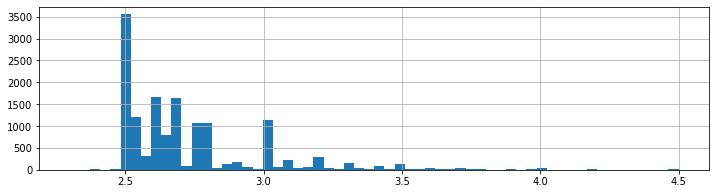

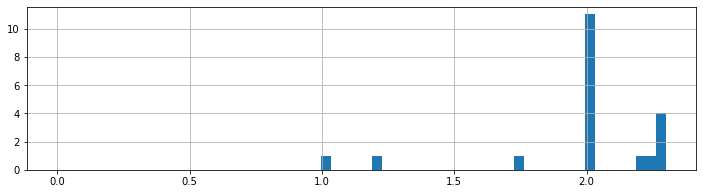

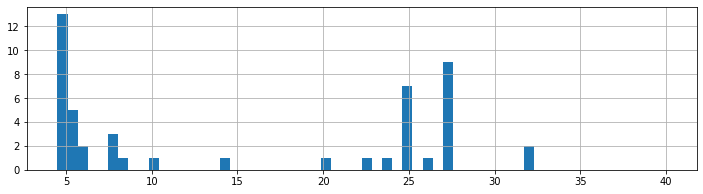

In [11]:
data['ceiling_height'].hist(figsize=(12,3), bins=60, range=(2.3, 4.5));
plt.show()
data['ceiling_height'].hist(figsize=(12,3), bins=60, range=(0,2.3));
plt.show()
data['ceiling_height'].hist(figsize=(12,3), bins=60, range=(4.5,40));

In [12]:
display(data.query('ceiling_height > 19 and ceiling_height < 35'))

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
355,17,3600000.0,55.2,2018-07-12,2,25.0,5.0,32.0,2,False,False,False,NaN,2.0,Гатчина,NaN,NaN,NaN,NaN,NaN,NaN,259.0
3148,14,2900000.0,75.0,2018-11-12,3,32.0,3.0,53.0,2,NaN,False,False,8.0,NaN,Волхов,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4643,0,4300000.0,45.0,2018-02-01,2,25.0,9.0,30.0,2,NaN,False,False,7.0,1.0,Санкт-Петербург,12016.0,13256.0,1.0,658.0,1.0,331.0,181.0
4876,7,3000000.0,25.0,2017-09-27,0,27.0,25.0,17.0,17,NaN,False,True,NaN,2.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,28.0
5076,0,3850000.0,30.5,2018-10-03,1,24.0,5.0,19.5,1,True,False,False,5.5,NaN,Санкт-Петербург,29686.0,8389.0,3.0,397.0,1.0,578.0,7.0
5246,0,2500000.0,54.0,2017-10-13,2,27.0,5.0,30.0,3,NaN,False,False,9.0,2.0,деревня Мины,NaN,NaN,NaN,NaN,NaN,NaN,540.0
5669,4,4400000.0,50.0,2017-08-08,2,26.0,9.0,21.3,3,NaN,False,False,7.0,2.0,Санкт-Петербург,28981.0,10912.0,1.0,305.0,0.0,NaN,267.0
5807,17,8150000.0,80.0,2019-01-09,2,27.0,36.0,41.0,13,NaN,False,False,12.0,5.0,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,38.0
6246,6,3300000.0,44.4,2019-03-25,2,25.0,5.0,31.3,5,NaN,False,False,5.7,NaN,Кронштадт,68923.0,50649.0,1.0,417.0,2.0,73.0,NaN
9379,5,3950000.0,42.0,2017-03-26,3,25.0,5.0,30.0,2,NaN,False,False,5.2,NaN,Санкт-Петербург,11647.0,13581.0,0.0,NaN,0.0,NaN,NaN


Судя данным из таблици (по цене, площади) это обычные квартиры с высотой от 2 до 4 метров. А двухзначные значения получились из-за того, что была пропущена запятая. Поэтому разделим эти значения на 10.

In [13]:
index_list = data.query('ceiling_height > 19 and ceiling_height < 35').index # Список индексов для проверки
data.loc[index_list, 'ceiling_height'] = data.loc[index_list, 'ceiling_height'] / 10

In [14]:
print(data.loc[index_list]['ceiling_height'])
print(data['ceiling_height'].tail(10))

355      2.50
3148     3.20
4643     2.50
4876     2.70
5076     2.40
5246     2.70
5669     2.60
5807     2.70
6246     2.50
9379     2.50
10773    2.70
11285    2.50
14382    2.50
17496    2.00
17857    2.70
18545    2.50
20478    2.70
20507    2.26
21377    2.75
21824    2.70
22336    3.20
22938    2.70
Name: ceiling_height, dtype: float64
23689    2.86
23690     NaN
23691    2.75
23692     NaN
23693    2.60
23694    3.70
23695     NaN
23696     NaN
23697    3.00
23698    2.50
Name: ceiling_height, dtype: float64


**Удалим строки где некорректные значения (их мало):**

Выше 35 (там только 100 -не реально, 10 тоже не реально )
ниже 1,9 ( это подвалы, наверно ),
От 7 до 19 (7-9 слишком выбивается из диапазона(уто уже 3-х уровневые квартиры:)) ),
10-19 - запятую не поставили (подвальный вариант))

In [15]:
# print(data.query('ceiling_height>35 or ceiling_height<1.9 or 7<ceiling_height<19')['ceiling_height'])
index_list = data.query('ceiling_height>35 or ceiling_height<1.9 or 7<ceiling_height<19').index
print(data.loc[index_list, 'ceiling_height'])

3474       8.00
5712       1.20
5863       8.30
15061     14.00
15743      8.00
16934      1.75
17442      8.00
22309     10.30
22590      1.00
22869    100.00
Name: ceiling_height, dtype: float64


In [16]:
print("Кол-во строк перед удалением", len(data))
data.drop(index_list, inplace=True, axis=0)
print("Кол-во строк после удаления", len(data))

data.reset_index(inplace=True, drop=True)
display(data.tail())

Кол-во строк перед удалением 23699
Кол-во строк после удаления 23689


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
23684,9,9700000.0,133.81,2017-03-21,3,3.7,5.0,73.3,3,NaN,False,False,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23685,14,3100000.0,59.00,2018-01-15,3,NaN,5.0,38.0,4,NaN,False,False,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23686,18,2500000.0,56.70,2018-02-11,2,NaN,3.0,29.7,1,NaN,False,False,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23687,13,11475000.0,76.75,2017-03-28,2,3.0,17.0,NaN,12,NaN,False,False,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0
23688,4,1350000.0,32.30,2017-07-21,1,2.5,5.0,12.3,1,NaN,False,False,9.00,NaN,поселок Новый Учхоз,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print(data['ceiling_height'].describe())
print(data['ceiling_height'].value_counts().head(15))

count    14494.000000
mean         2.726623
std          0.278702
min          2.000000
25%          2.510000
50%          2.650000
75%          2.800000
max          6.000000
Name: ceiling_height, dtype: float64
2.50    3522
2.60    1647
2.70    1582
3.00    1112
2.80     993
2.55     980
2.75     911
2.65     676
3.20     279
3.10     203
2.90     164
3.30     141
2.56     139
3.50     130
2.57     103
Name: ceiling_height, dtype: int64


Теперь переводим высоту в сантиметры:

In [18]:
data['ceiling_height'] = data['ceiling_height'] * 100
print(data['ceiling_height'].describe())

count    14494.000000
mean       272.662343
std         27.870225
min        200.000000
25%        251.000000
50%        265.000000
75%        280.000000
max        600.000000
Name: ceiling_height, dtype: float64


Теперь решаем проблему с пропусками:

In [19]:
print("Кол-во пропусков =", data['ceiling_height'].isna().sum())
print(data['ceiling_height'].describe())
print(data['ceiling_height'].value_counts())

Кол-во пропусков = 9195
count    14494.000000
mean       272.662343
std         27.870225
min        200.000000
25%        251.000000
50%        265.000000
75%        280.000000
max        600.000000
Name: ceiling_height, dtype: float64
250.0    3522
260.0    1647
270.0    1582
300.0    1112
280.0     993
         ... 
490.0       1
249.0       1
388.0       1
560.0       1
358.0       1
Name: ceiling_height, Length: 168, dtype: int64


Для замены лучше всего подойдет медианное значение столбца 265см (оно не подверженно влиянию тех значений которые расположены по концам столбца, где могут быть сильные отклонения, влияющие на среднюю величину)

In [20]:
data['ceiling_height'] = data['ceiling_height'].fillna(265)

In [21]:
print("Кол-во пропусков =", data['ceiling_height'].isna().sum())
print()
print(data['ceiling_height'].describe())

Кол-во пропусков = 0

count    23689.000000
mean       269.688168
std         22.117452
min        200.000000
25%        260.000000
50%        265.000000
75%        270.000000
max        600.000000
Name: ceiling_height, dtype: float64


И поменяем тип на *int*

In [22]:
print('Длина всего data =',len(data))
print()
data['ceiling_height'] = data['ceiling_height'].astype('int')
print(data['ceiling_height'].describe())
print()
print("Тип столбца -",data['ceiling_height'].dtype)

Длина всего data = 23689

count    23689.000000
mean       269.642155
std         22.148208
min        200.000000
25%        260.000000
50%        265.000000
75%        270.000000
max        600.000000
Name: ceiling_height, dtype: float64

Тип столбца - int64


_**Вывод: Столбец готов**_

_**3.Столбец "floors_total"**_

Пропусков мало, нужен анализ совместно со столбцом floor, поменяем тип на *int*

In [23]:
print(data['floors_total'].value_counts())
display(data.query('floors_total.isna()').head(7))

5.0     5785
9.0     3761
16.0    1373
12.0    1361
4.0     1200
10.0    1174
25.0    1075
6.0      914
17.0     833
3.0      668
7.0      592
14.0     552
18.0     505
24.0     469
8.0      390
2.0      382
15.0     365
23.0     352
19.0     339
22.0     286
20.0     271
13.0     229
11.0     203
27.0     164
21.0     158
26.0     124
1.0       25
35.0      24
28.0      21
36.0       3
29.0       1
60.0       1
52.0       1
34.0       1
33.0       1
Name: floors_total, dtype: int64


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
186,12,11640000.0,65.20,2018-10-02,2,265,NaN,30.80,4,NaN,False,False,12.00,NaN,Санкт-Петербург,39197.0,12373.0,1.0,123.0,0.0,NaN,49.0
237,4,2438033.0,28.10,2016-11-23,1,265,NaN,20.75,1,NaN,False,False,NaN,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,251.0
457,4,9788348.0,70.80,2015-08-01,2,265,NaN,38.40,12,NaN,False,False,10.63,0.0,Санкт-Петербург,37364.0,8322.0,2.0,309.0,2.0,706.0,727.0
671,4,6051191.0,93.60,2017-04-06,3,265,NaN,47.10,8,NaN,False,False,16.80,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,123.0
1757,5,3600000.0,39.00,2017-04-22,1,265,NaN,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,22735.0,11618.0,1.0,835.0,1.0,652.0,77.0
1930,1,9750000.0,66.77,2016-05-13,2,265,NaN,NaN,4,NaN,False,False,NaN,0.0,Санкт-Петербург,39886.0,10660.0,1.0,2276.0,3.0,244.0,90.0
2392,7,5395770.0,53.00,2017-06-29,2,265,NaN,29.00,22,NaN,False,False,9.00,0.0,Санкт-Петербург,43074.0,10820.0,0.0,NaN,0.0,NaN,48.0


Удалим пропуски в столбце "floor", поскольку строк всего 86, и это менее 1%. И на результат это мало повлияет):

In [24]:
data = data.dropna(subset=['floors_total']) 
print(data['floors_total'].value_counts().head(7))

5.0     5785
9.0     3761
16.0    1373
12.0    1361
4.0     1200
10.0    1174
25.0    1075
Name: floors_total, dtype: int64


И поменяем тип на *int*

In [25]:
data['floors_total'] = data['floors_total'].astype('int')
print(f'Длина всего датасета = {len(data)} // Длина заполненого floors_total = \
{data["floors_total"].count()} // Тип = {data["floors_total"].dtype}')

Длина всего датасета = 23603 // Длина заполненого floors_total = 23603 // Тип = int64


_**4. Столбец "living_area" и столбец "kitchen_area"**_

*living_area - 8% пропусков - довольно много, надо проанализировать*
*kitchen_area - 9% пропусков - довольно много, надо проанализировать*

Надо прояснить следующее: в общепринятом понимании Общая площадь квартиры = Кухня + Жилая + Нежилая. Балкон в площадь не входит(если это не лоджия). В квартирах-студиях Общая = Жилая + Нежилая. Аппартаменты = Квартира

Сначала заполним (с учетом среднего значения доли жилой площади к общей) 

*"living_area"* в студиях (если требуется)
(*прим.* столбец студий мы проверили (он корректен) , он будет дальше)

In [26]:
print("Студий Всего",len(data.loc[data['studio']==True]))
print()
print("Студий с заполненными значениями", data.loc[data['studio']==True, 'living_area'].describe())
print(data['studio'].value_counts())

Студий Всего 146

Студий с заполненными значениями count    139.000000
mean      18.995396
std        7.345598
min        2.000000
25%       16.000000
50%       18.000000
75%       19.850000
max       68.000000
Name: living_area, dtype: float64
False    23457
True       146
Name: studio, dtype: int64


Присутствуют слишком маленькие жилые площади min=2, непорядок. Считаю, это потому, что не был дописан 0. Разберемся подробнее:

          xd     yd
144    27.00  15.50
440    27.11  24.75
697    24.10  17.50
716    17.00  12.00
1173   29.00  17.00
...      ...    ...
22823  28.00  16.80
22858  30.00  18.20
22867  28.00  18.00
23200  26.00  18.00
23627  26.00  17.00

[139 rows x 2 columns]


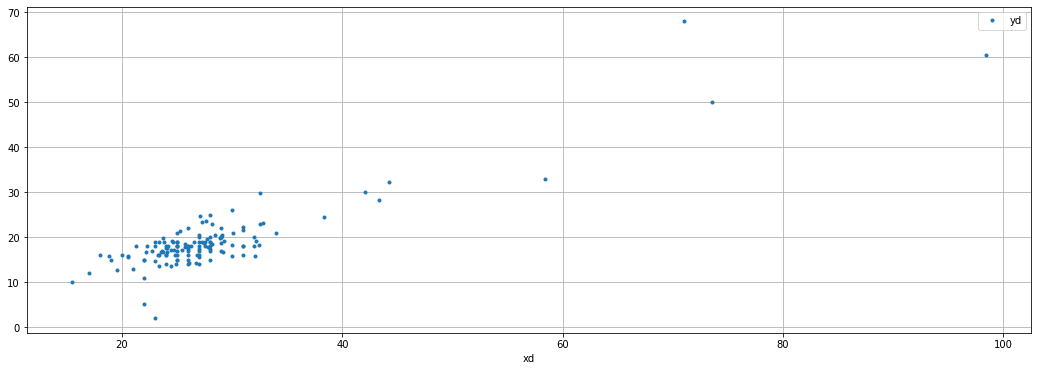

In [27]:
graf = pd.DataFrame(columns=['xd','yd']) # [Вся_площадь, Жилая]
graf['yd'] = data.loc[(data['living_area'].isna() == False) & (data['studio']==True), 'living_area']
graf['xd'] = data.loc[(data['living_area'].isna() == False) & (data['studio']==True), 'total_area']
print(graf)

graf.plot(y='yd', x='xd', style=".", figsize=(18,6), grid=True);

Видно, что есть нереалистичные значения, где общая площадь меньше жилой или жилая совсем мала. Рассмотрим подрдбнее

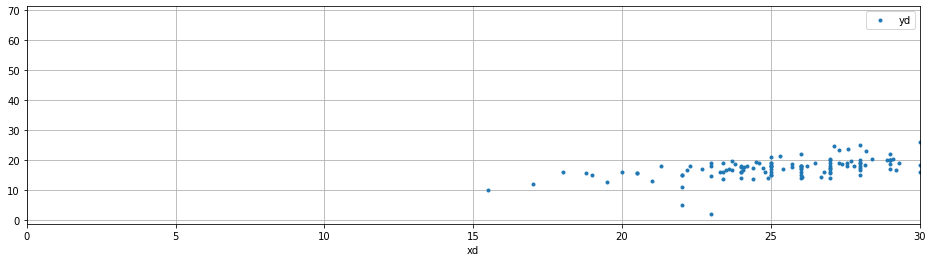

In [28]:
graf.plot(y='yd', x='xd', style=".", figsize=(16,4), grid=True, xlim=(0,30));

На этом графике нет значений, где общая площадь меньше жилой. Есть пара слишком маденьких значений жилой площади. Скорее всего это получилось из-за того , что не поставили 1 в разряде десятков. Исправим эти значения прибавив к ним 10

In [29]:
index_list = data.loc[(data['living_area']<10) & (data['studio']==True), ['living_area', 'total_area']].index
print(data.loc[index_list, ['living_area', 'total_area']])
data.loc[(data['living_area']<10) & (data['studio']==True), 'living_area'] +=10 # Прибавляем 10
print(data.loc[index_list, ['living_area', 'total_area']])

       living_area  total_area
17575          5.0        22.0
21751          2.0        23.0
       living_area  total_area
17575         15.0        22.0
21751         12.0        23.0


Исправили. Теперь в студиях значения жилой площади выглядят реалистично.

Теперь заполним пропуски в студиях (жилые) в соответствии со средним значением доли жилой к общей.

In [30]:
print("Кол-во студий со значением =", data.loc[(data['living_area'].isna() == False) & (data['studio']==True), \
        'living_area'].count(), " // Кол-во студий всего =", data.loc[data['studio']==True, 'total_area'].count())
print()
part_live_in_studio = data.loc[data['studio']==True, 'living_area'] / data.loc[data['studio']==True, 'total_area']
print(part_live_in_studio.head())
print()

# Средняя доля жилой в студиях
part_live_in_studio = part_live_in_studio.dropna().mean() # Удаляем строки с NaN и считаем среднее
print("Средняя доля жилой площади в студии =", part_live_in_studio)
print()

# Меняем значение жилой в студии на = доля*общую
data.loc[(data['living_area'].isna() == True) & (data['studio']==True), 'living_area'] = \
    data.loc[(data['living_area'].isna() == True) & (data['studio']==True), 'total_area'] * part_live_in_studio

Кол-во студий со значением = 139  // Кол-во студий всего = 146

144    0.574074
440    0.912947
608         NaN
697    0.726141
716    0.705882
dtype: float64

Средняя доля жилой площади в студии = 0.6879269478769845



In [31]:
# Проверим
print("Кол-во студий со значением =", data.loc[(data['living_area'].isna() == False) & (data['studio']==True), \
        'living_area'].count(), " // Кол-во студий всего =", len(data.loc[data['studio']==True]))

display(data.query('studio==True'))

Кол-во студий со значением = 146  // Кол-во студий всего = 146


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
144,1,2450000.0,27.00,2017-03-30,0,265,24,15.500000,2,NaN,True,False,NaN,2.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,181.0
440,8,2480000.0,27.11,2018-03-12,0,265,17,24.750000,4,NaN,True,False,NaN,2.0,Санкт-Петербург,38171.0,15015.0,0.0,NaN,2.0,982.0,64.0
608,2,1850000.0,25.00,2019-02-20,0,265,10,17.198174,7,NaN,True,False,NaN,NaN,посёлок Шушары,NaN,NaN,NaN,NaN,NaN,NaN,29.0
697,12,2500000.0,24.10,2017-12-01,0,275,25,17.500000,21,NaN,True,False,NaN,NaN,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,201.0
716,5,1500000.0,17.00,2017-06-07,0,270,9,12.000000,1,NaN,True,False,NaN,0.0,посёлок Шушары,18654.0,29846.0,0.0,NaN,0.0,NaN,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22858,8,3090000.0,30.00,2017-12-17,0,265,25,18.200000,5,NaN,True,False,NaN,NaN,Санкт-Петербург,35250.0,16414.0,0.0,NaN,1.0,400.0,211.0
22867,2,4280000.0,28.00,2017-10-26,0,270,19,18.000000,10,NaN,True,False,NaN,NaN,Санкт-Петербург,18982.0,7206.0,0.0,NaN,1.0,415.0,151.0
23200,7,3200000.0,26.00,2017-09-01,0,265,25,18.000000,16,NaN,True,False,NaN,0.0,Санкт-Петербург,11405.0,13222.0,0.0,NaN,1.0,623.0,14.0
23544,15,3350000.0,26.00,2018-09-07,0,265,19,17.886101,8,NaN,True,False,NaN,NaN,Санкт-Петербург,18090.0,17092.0,0.0,NaN,2.0,112.0,31.0


Теперь заполним пропуски медианными значениями *"living_area"* в зависимости от *"total_area"*, логично предположить (и жизненный опыт это подтвердит) что, чем больше общая площадь, тем больше площадь жилая и кухни, и тем больше доля другой(нежилой площади). Выведем диаграмму  *"living_area"* в *"total_area"* в зависимости от *"total_area"* и на будущее параллельно сделаем тоже для *"kitchen_area"*. Только исключим из анализа квартиры студии (так как мы их обработали)

* _Будем рассматривать 3 площади вместе (так как они взаимосвязаны) - общая, жилая, кухня_

Заполним пропуски площади *"kitchen_area"*, потом *"living_area"*, а затем еще проверим их сумму(она не должна быть больше общей площади), и скорректируем при необходимости.

In [32]:
display(data.loc[:,['total_area', 'living_area', 'kitchen_area']])

,total_area,living_area,kitchen_area
0,108.00,51.0,25.00
1,40.40,18.6,11.00
2,56.00,34.3,8.30
3,159.00,NaN,NaN
4,100.00,32.0,41.00
...,...,...,...
23684,133.81,73.3,13.83
23685,59.00,38.0,8.50
23686,56.70,29.7,NaN
23687,76.75,NaN,23.30


In [33]:
print('-=Все значения рассчитываются, исключая студии=-')
print()
print("Кол-во квартир всего =", len(data.loc[data['studio']==False]))

print("Кол-во квартир со значением в жилой =", data.loc[(data['living_area'].isna() == False) & \
                                                        (data['studio']==False), 'living_area'].count(), )

print("Кол-во квартир со значением в кухне =", data.loc[(data['kitchen_area'].isna() == False) & \
                                                        (data['studio']==False), 'kitchen_area'].count(), )

-=Все значения рассчитываются, исключая студии=-

Кол-во квартир всего = 23457
Кол-во квартир со значением в жилой = 21594
Кол-во квартир со значением в кухне = 21374


Для удобства сделаем отдельный ДатаФрейм (без Студий)- Здесь будут оригиналы (для сравнения и вывода графиков)

In [34]:
sq = pd.DataFrame(columns=['all','liv', 'kit']) # [Вся_площадь, Жилая, Кухня] - Здесь будут оригиналы
sq['all'] = data.loc[(data['total_area'].isna() == False) & (data['studio']==False), 'total_area']
sq['liv'] = data.loc[(data['living_area'].isna() == False) & (data['studio']==False), 'living_area']
sq['kit'] = data.loc[(data['kitchen_area'].isna() == False) & (data['studio']==False), 'kitchen_area']
print(sq)
print()

print("проверка совпадает ли с оригиналом")
print(data.loc[data['studio']==False, ['total_area', 'living_area', 'kitchen_area']])

          all   liv    kit
0      108.00  51.0  25.00
1       40.40  18.6  11.00
2       56.00  34.3   8.30
3      159.00   NaN    NaN
4      100.00  32.0  41.00
...       ...   ...    ...
23684  133.81  73.3  13.83
23685   59.00  38.0   8.50
23686   56.70  29.7    NaN
23687   76.75   NaN  23.30
23688   32.30  12.3   9.00

[23457 rows x 3 columns]

проверка совпадает ли с оригиналом
       total_area  living_area  kitchen_area
0          108.00         51.0         25.00
1           40.40         18.6         11.00
2           56.00         34.3          8.30
3          159.00          NaN           NaN
4          100.00         32.0         41.00
...           ...          ...           ...
23684      133.81         73.3         13.83
23685       59.00         38.0          8.50
23686       56.70         29.7           NaN
23687       76.75          NaN         23.30
23688       32.30         12.3          9.00

[23457 rows x 3 columns]


Рассчитаем Медианы и Средние доли кухни и жилой в общей площади а также добавим долю оставшейся площади *(part_other)*

In [35]:
part_kit = sq['kit'] / sq['all']
part_kit_median = part_kit.dropna().median()
part_kit_mean = part_kit.dropna().mean()
print("part_kit_median =", part_kit_median, "// part_kit_mean =", part_kit_mean)
print()
part_liv = sq['liv'] / sq['all']
part_liv_median = part_liv.dropna().median()
part_liv_mean = part_liv.dropna().mean()
print("part_liv_median =", part_liv_median, "// part_liv_mean =", part_liv_mean)

part_kit_median = 0.17233373477853606 // part_kit_mean = 0.18731645683419906

part_liv_median = 0.5673758865248227 // part_liv_mean = 0.5642168007653031


Медиана и среднее мало отличаются. Выберем медиану для дальнейших действий

In [36]:
part_kit = part_kit_median
part_liv = part_liv_median
part_other = 1 - part_liv_median - part_kit_median
print('part_other =',part_other)

part_other = 0.2602903786966412


Заполним пропуски в столбцах кухня и жилая значениями = (медиана x общую)

In [37]:
ind_nan_kit = data.loc[(data['kitchen_area'].isna() == True) & (data['studio']==False)].index 
# Индексы где пропуски в значениях 'kitchen_area'
data.loc[ind_nan_kit, 'kitchen_area'] = part_kit * data.loc[ind_nan_kit, 'total_area']

In [38]:
print(data['kitchen_area'].describe())

count    23457.000000
mean        10.524728
std          6.030959
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64


In [39]:
ind_nan_liv = data.loc[(data['living_area'].isna() == True) & (data['studio']==False)].index 
# Индексы где пропуски в значениях 'living_area'
data.loc[ind_nan_liv, 'living_area'] = part_liv * data.loc[ind_nan_liv, 'total_area']

In [40]:
print(data['living_area'].describe())

count    23603.000000
mean        34.589695
std         22.352429
min          2.000000
25%         19.000000
50%         30.000000
75%         42.100000
max        409.700000
Name: living_area, dtype: float64


Видно что присутствуют слишком маленькие значения как в кухнях (min = 1,3), так и в жилых (min = 2)

Некорректные значения в кухнях:

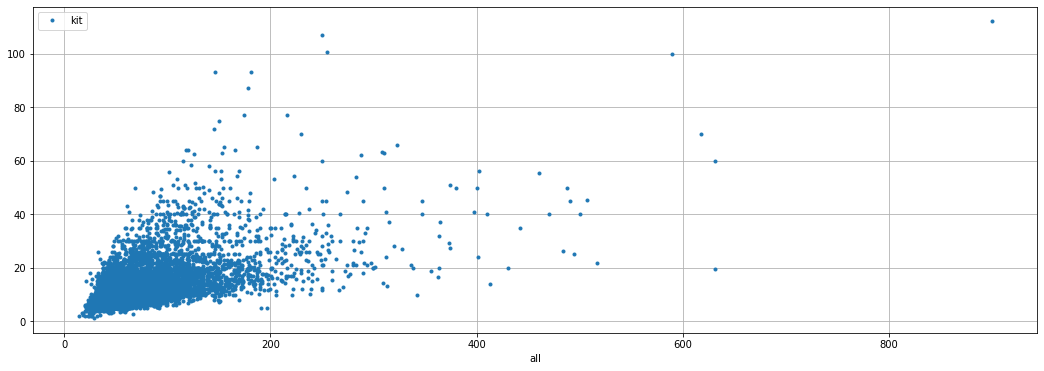

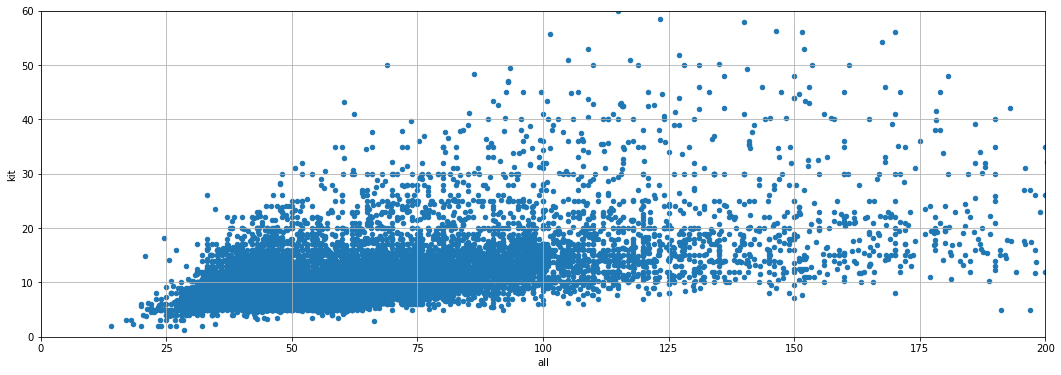

In [41]:
sq['kit'].describe()
sq.plot(y='kit', x='all', style=".", figsize=(18,6), grid=True);
plt.show
sq.plot(y='kit', x='all', kind='scatter', figsize=(18,6), grid=True, xlim=(0, 200), ylim=(0, 60));

Видно что есть слишком маленькие и слишком большие значения (их мало) кухни. Установим разумные пределы кухни (min_kit = 4 и max_kit = 40) и все что выходит за пределы заменим на предельные значения соответственно.

In [42]:
min_kit = 3
max_kit = 40

data.loc[(data['kitchen_area']<min_kit) & (data['studio']==False), 'kitchen_area'] = min_kit
data.loc[(data['kitchen_area']>max_kit) & (data['studio']==False), 'kitchen_area'] = max_kit

data.loc[(data['studio']==False),'kitchen_area'].describe()

count    23457.000000
mean        10.440951
std          5.382482
min          3.000000
25%          7.000000
50%          9.000000
75%         12.000000
max         40.000000
Name: kitchen_area, dtype: float64

Проверим, есть ли очень маленькие и большиие значения в жилой *('living_area')*

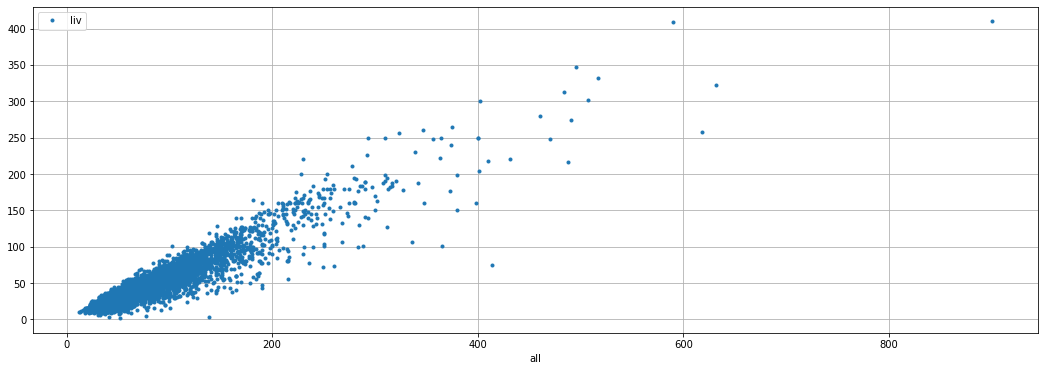

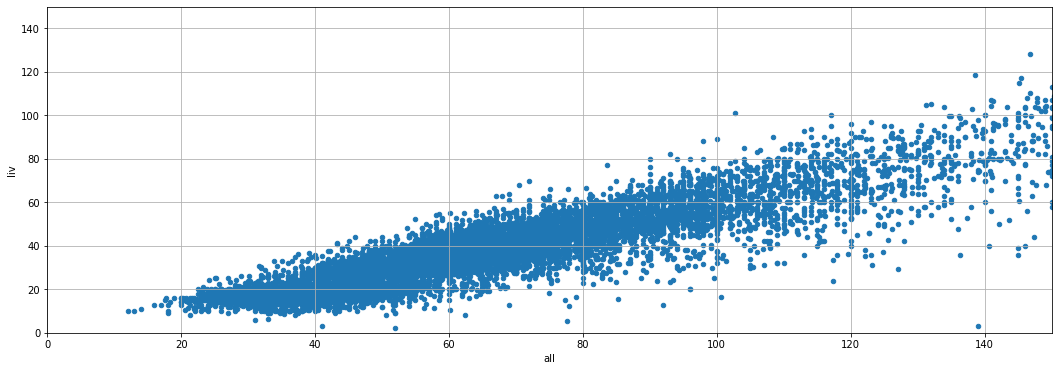

In [43]:
sq['liv'].describe()
sq.plot(y='liv', x='all', style=".", figsize=(18,6), grid=True);
plt.show
sq.plot(y='liv', x='all', kind='scatter', figsize=(18,6), grid=True, xlim=(0, 150), ylim=(0, 150));

In [44]:
print('Общая площадь :')
data.loc[(data['studio']==False),'total_area'].describe()

Общая площадь :


count    23457.000000
mean        60.549271
std         35.664781
min         12.000000
25%         40.000000
50%         52.000000
75%         70.000000
max        900.000000
Name: total_area, dtype: float64

Есть значения, при которых жилая площадь слишком мала по сравнению с общей при медиане доли - *part_liv_median* = 0.567 (56,7%)
Малыми площадями будем считать если они меньше 30% от общей
Заполним эти значения 40% (~середина между общ-56,7% и нежил-26.6%) от общей площадей.
Также установим минимальный размер жилой площади = 5 кв.м (уж меньше некуда)
И еще сделаем корректировку для квартир с общей площадью < 140 кв.м (там где площадь больше чем 140, там более менее сносные значения, и в них сильно будут отличаться от средней пропорции жилой/нежилой/кухни)

In [45]:
ind_lst = data.loc[ (data['living_area'] < data['total_area']*0.3) & (data['total_area']<140) & (data['studio']==False) ].index
data.loc[ind_lst, 'living_area'] = data.loc[ind_lst, 'total_area'] * 0.4

count    23603.000000
mean        34.650189
std         22.318223
min          7.375887
25%         19.000000
50%         30.000000
75%         42.100000
max        409.700000
Name: living_area, dtype: float64


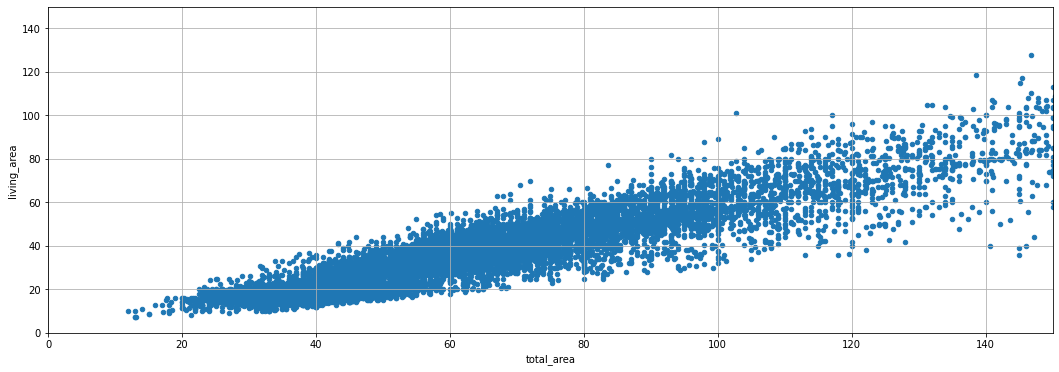

In [46]:
# Проверим:
print(data['living_area'].describe())
data[(data['studio']==False)].plot(
    y='living_area', x='total_area', kind='scatter', figsize=(18,6), grid=True, xlim=(0, 150), ylim=(0, 150));

Теперь проверим корректность проделанного. Сверим оставшиеся помещения - другие (нежилые = общая - жилая - кухня) с разумным минимумом равным 4 кв.м (коридор=1,5 + (туалет+ванна)=2,5 = 4). Итого в самой маленькой квартире 12кв.м = 3кух + 5жил + 4нежил Минимум 7,37 - по минимуму проходим. (зато по общей площади теперь переполнение) Вспомним и запишем минимумы:
kit_min = 3
liv_min = 5
noliv_min = 4

In [47]:
kit_min = 3
liv_min = 5
noliv_min = 4


# Индексы где другая (нежилая) площадь меньше noliv_min
ind_small_noliv = data.loc[ (data['studio']==False) & (((data['total_area'] - data['living_area'] - \
                                                        data['kitchen_area']) < noliv_min) )].index
display(data.loc[ind_small_noliv,['total_area', 'living_area','kitchen_area']])

# Выводим значения со слишком маленькой нежилой площадья
square_table = data.loc[ind_small_noliv,'total_area'] - data.loc[ind_small_noliv,'living_area'] - \
data.loc[ind_small_noliv,'kitchen_area']
print(square_table)
square_table.describe()


# ind_small_noliv_part = data.loc[ (data['studio']==False) & ((data['total_area'] - data['living_area'] - \
#                                                         data['kitchen_area']) < data['total_area']*part_other)]

# other_area = data['total_area'] - data['living_area'] - data['kitchen_area']

# ind_small_noliv = data.query( '(studio==False) and ( ((total_area-living_area-kitchen_area)<@noliv_min) or \
# ((total_area-living_area-kitchen_area)<@part_other*total_area) )').index

# def other_column(tot,liv,kit):
#     return (tot-liv-kit)
# square_table = data.pivot_table(index=ind_small_noliv, \
#                          values=['total_area', 'living_area','kitchen_area'], aggfunc = 'other_column')

,total_area,living_area,kitchen_area
41,74.0,59.0,12.000000
171,49.0,38.0,10.000000
184,30.2,26.1,6.200000
220,37.0,28.0,9.000000
349,25.0,17.0,4.308343
...,...,...,...
23287,48.2,42.2,6.000000
23569,24.8,18.0,4.273877
23600,29.0,18.6,6.600000
23601,37.0,25.0,8.020000


41       3.000000
171      1.000000
184     -2.100000
220      0.000000
349      3.691657
           ...   
23287    0.000000
23569    2.526123
23600    3.800000
23601    3.980000
23670    0.000000
Length: 503, dtype: float64


count    503.000000
mean       0.359163
std        4.089603
min      -29.636759
25%        0.000000
50%        1.300000
75%        2.902745
max        3.980000
dtype: float64

Даже присутствуют отрицательные значения. Восполним остальную площадь до минимума (5кв.м) за счет жилой и кухни. Будем урезать каждую на 2%, пока пока не будут достигнуты минимумы или другая(нежилая) станет около 5 кв.м
Напишем функцию *cut_square(ind)* которая будет принимать индекс некорректной строки и "подрезать" площади, если удачно возвращает 0 если нет *ind*

In [48]:
def cut_square(ind):
    kit = data.loc[ind, 'kitchen_area']
    liv = data.loc[ind, 'living_area']
    tot = data.loc[ind, 'total_area']
    kit_min = 3
    liv_min = 5
    noliv_min = 4
    cut = 0.98 # Коэффициент на который надо умножить чтобы обрезать значение на 2%
    while noliv_min >= tot - kit - liv:
        if liv > liv_min:
            liv = liv * cut  # Обрезаем на 2% жилую
        if kit > kit_min:
            kit = kit * cut  # Обрезаем на 2% кухню
        
    noliv = tot - kit - liv    
    data.loc[ind, 'kitchen_area'] = kit
    data.loc[ind, 'living_area'] = liv
    return [ind, tot, liv, kit, noliv] # Соберем
    
# ------------------------------------    

# i = []
c=0 # Счетчик замен
for index in ind_small_noliv:
#     i.append(cut_square(index))
    print(data.loc[index,['total_area', 'living_area', 'kitchen_area']])
    print(cut_square(index))
    print(data.loc[index,['total_area', 'living_area', 'kitchen_area']])
#     input()
    print()
    c+=1
print("Произведенено замен =",c)

total_area      74.0
living_area     59.0
kitchen_area    12.0
Name: 41, dtype: object
[41, 74.0, 57.82, 11.76, 4.420000000000002]
total_area       74.0
living_area     57.82
kitchen_area    11.76
Name: 41, dtype: object

total_area      49.0
living_area     38.0
kitchen_area    10.0
Name: 171, dtype: object
[171, 49.0, 35.04999008000001, 9.2236816, 4.726328319999993]
total_area          49.0
living_area     35.04999
kitchen_area    9.223682
Name: 171, dtype: object

total_area      30.2
living_area     26.1
kitchen_area     6.2
Name: 184, dtype: object
[184, 30.2, 20.899088254569673, 4.964534374648734, 4.3363773707815945]
total_area           30.2
living_area     20.899088
kitchen_area     4.964534
Name: 184, dtype: object

total_area      37.0
living_area     28.0
kitchen_area     9.0
Name: 220, dtype: object
[220, 37.0, 24.803586664192, 7.972581427775999, 4.223831908032]
total_area           37.0
living_area     24.803587
kitchen_area     7.972581
Name: 220, dtype: object

total_are

In [49]:
square_table = data.loc[ind_small_noliv,'total_area'] - data.loc[ind_small_noliv,'living_area'] - \
data.loc[ind_small_noliv,'kitchen_area']
print(square_table)
print(square_table.describe())
data.loc[:,['total_area','living_area','kitchen_area']].describe()

41       4.420000
171      4.726328
184      4.336377
220      4.223832
349      4.117823
           ...   
23287    4.631018
23569    4.255285
23600    4.304000
23601    4.640400
23670    4.580279
Length: 503, dtype: float64
count    503.000000
mean       4.419535
std        0.361768
min        4.002709
25%        4.172904
50%        4.336377
75%        4.542200
max        7.284594
dtype: float64


,total_area,living_area,kitchen_area
count,23603.000000,23603.000000,23457.000000
mean,60.346746,34.585969,10.418503
std,35.654465,22.299373,5.358693
min,12.000000,4.930746,2.942756
25%,40.000000,19.000000,7.000000
50%,52.000000,30.000000,9.000000
75%,69.800000,42.100000,12.000000
max,900.000000,409.700000,40.000000


Немного вылезли некоторые значения *'living_area', 'kitchen_area'* за 5 и 3 кв.м, это получилось из-за того, что значения при корректировке были чуть выше kit_min = 3 / liv_min = 5 и -2% получим, что имеем. Можно было отрезать не по 2%, а,например, по 0,1%, тогда отклонение было бы меньше. Полученый результат вполне допустим.

Теперь для примера округлим значения 'living_area', 'kitchen_area' до одной десятой

In [50]:
print(data[['living_area', 'kitchen_area']].head(7))
data[['living_area', 'kitchen_area']] = round(data[['living_area', 'kitchen_area']],1)
print(data[['living_area', 'kitchen_area']].head(7))

   living_area  kitchen_area
0    51.000000     25.000000
1    18.600000     11.000000
2    34.300000      8.300000
3    90.212766     27.401064
4    32.000000     40.000000
5    14.400000      9.100000
6    14.920000     14.400000
   living_area  kitchen_area
0         51.0          25.0
1         18.6          11.0
2         34.3           8.3
3         90.2          27.4
4         32.0          40.0
5         14.4           9.1
6         14.9          14.4


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23603 entries, 0 to 23688
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23603 non-null  int64         
 1   last_price            23603 non-null  float64       
 2   total_area            23603 non-null  float64       
 3   first_day_exposition  23603 non-null  datetime64[ns]
 4   rooms                 23603 non-null  int64         
 5   ceiling_height        23603 non-null  int64         
 6   floors_total          23603 non-null  int64         
 7   living_area           23603 non-null  float64       
 8   floor                 23603 non-null  int64         
 9   is_apartment          2773 non-null   object        
 10  studio                23603 non-null  bool          
 11  open_plan             23603 non-null  bool          
 12  kitchen_area          23457 non-null  float64       
 13  balcony         

**Вывод:** *'living_area', 'kitchen_area'* - готовы, но надо помнить что , в строках, где квартиры-студии в колонке кухни будет стоять NaN (149 строк). В отчете это видно.

_**5. Столбец "balcony"**_

Заполним пропуски "0"(т.к. логично что балкона нет).

In [52]:
print(data['balcony'].value_counts())
print()
print("Кол-во NaN =",data['balcony'].isna().sum())

1.0    4193
0.0    3713
2.0    3656
5.0     303
4.0     183
3.0      81
Name: balcony, dtype: int64

Кол-во NaN = 11474


In [53]:
data['balcony'] = data['balcony'].fillna(0)
print(data['balcony'].value_counts())
print("Кол-во NaN =",data['balcony'].isna().sum())

0.0    15187
1.0     4193
2.0     3656
5.0      303
4.0      183
3.0       81
Name: balcony, dtype: int64
Кол-во NaN = 0


In [54]:
data['balcony'].dtype
data['balcony'] = data['balcony'].astype(int)
data['balcony'].dtype

dtype('int64')

**Вывод:** NaN поменяли на 0 (так больше похоже на правду) и поменяли тип на *int*

_**6. Столбец "locality_name"**_

In [55]:
print(data['locality_name'].value_counts())
print()
print("Кол-во пропущеных значений", data['locality_name'].isna().sum())
print()
display(data['locality_name'].sort_values().unique())

Санкт-Петербург             15644
посёлок Мурино                520
посёлок Шушары                439
Всеволожск                    398
Пушкин                        369
                            ...  
деревня Старое Хинколово        1
село Никольское                 1
деревня Тихковицы               1
деревня Каськово                1
деревня Ялгино                  1
Name: locality_name, Length: 364, dtype: int64

Кол-во пропущеных значений 48



array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалёво',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Янино-1',
       'городской посёлок Будогощь', 'городской посёлок Виллози',
       'городской посёлок Лесогорский', 'городской посёлок Мга',
       'городской посёлок Назия', 'городской посёлок Новоселье',
       'городской посёлок Павлово', 'городской посёлок Рощино',
       'городской посёлок Свирьстрой', 'городской посёлок Совет

Всего 49 пропусков ( 0,2% ). 
Видно, что слово посёлок написано в 2 вариантах с "ё" и "е".

In [56]:
# заменим все "ё" на "е" во всем столбце 'locality_name'
import re
i = 0 # счетчик строк где Ё и ё
# for ind_str in data.loc[(data['locality_name']!=np.nan),'locality_name'].index:
for ind_str in data.loc[(data['locality_name'].isna()==False),'locality_name'].index:    
    loc_str = data.loc[ind_str, 'locality_name']
    if ('ё' or 'Ё') in loc_str:
#         print(loc_str)
        i+=1
        loc_str = re.sub('ё', 'е', loc_str)
        loc_str = re.sub('Ё', 'Е', loc_str)
#         print(loc_str)
    data.loc[ind_str, 'locality_name'] = loc_str
#     print(data.loc[ind_str, 'locality_name'])
print()
print("Кол-во строк где произведена замена =", i)


Кол-во строк где произведена замена = 2138


In [57]:
print(data['locality_name'].value_counts())

Санкт-Петербург               15644
поселок Мурино                  552
поселок Шушары                  439
Всеволожск                      398
Пушкин                          369
                              ...  
поселок Алексеевка                1
деревня Куровицы                  1
садовое товарищество Садко        1
деревня Пижма                     1
деревня Пчева                     1
Name: locality_name, Length: 330, dtype: int64


Проверим наличие одних и тех же имен населенных пунктов, записанных по-разному (сравним их леммы). 
Изначально имен 330.

In [58]:
from pymystem3 import Mystem 
m = Mystem()

#   Создадим и заполним ДатаФрейм где 3 столбца : 
#   'original' - оригинал строки, 'lemm' - Лемматизированная строка, 
#   'name' - лемматизированное имя населенного пункта
loc_df = pd.DataFrame(columns=['original', 'lemm', 'name'])
loc_df['original'] = data.loc[(data['locality_name'].isna()==False),'locality_name'].sort_values(na_position='last').unique()

for ind in loc_df.index:
    lem_str = m.lemmatize(loc_df.loc[ind, 'original'])
    loc_df.loc[ind, 'lemm'] = lem_str
    loc_df.loc[ind, 'name'] = lem_str[-2]

display(loc_df)

print(loc_df['lemm'].value_counts())

,original,lemm,name
0,Бокситогорск,"[бокситогорск, \n]",бокситогорск
1,Волосово,"[волосово, \n]",волосово
2,Волхов,"[волхов, \n]",волхов
3,Всеволожск,"[всеволожск, \n]",всеволожск
4,Выборг,"[выборг, \n]",выборг
...,...,...,...
325,село Путилово,"[село, , путиловый, \n]",путиловый
326,село Рождествено,"[село, , рождествено, \n]",рождествено
327,село Русско-Высоцкое,"[село, , русский, -, высоцкий, \n]",высоцкий
328,село Старая Ладога,"[село, , старый, , ладога, \n]",ладога


[поселок,  , саперный, \n]                           2
[поселок,  , городской,  , тип,  , сиверский, \n]    1
[поселок,  , барышево, \n]                           1
[поселок,  , первомайский, \n]                       1
[приозерск, \n]                                      1
                                                    ..
[кировск, \n]                                        1
[деревня,  , сижно, \n]                              1
[поселок,  , репино, \n]                             1
[деревня,  , вахнов,  , кара, \n]                    1
[деревня,  , торошкович, \n]                         1
Name: lemm, Length: 329, dtype: int64


[поселок, , саперный, \n] повторяется 2 раза. Выясним *"original"* названия

In [59]:
display(loc_df[loc_df['name']=='саперный'])

,original,lemm,name
247,поселок Саперное,"[поселок, , саперный, \n]",саперный
248,поселок Саперный,"[поселок, , саперный, \n]",саперный


Можно проверить по расстоянию от центра или с помощью других расстояний, но проще воспользоваться Википедией:

Сапёрное - https://ru.wikipedia.org/wiki/%D0%A1%D0%B0%D0%BF%D1%91%D1%80%D0%BD%D0%BE%D0%B5

Сапёрный - https://ru.wikipedia.org/wiki/%D0%A1%D0%B0%D0%BF%D1%91%D1%80%D0%BD%D1%8B%D0%B9_(%D0%A1%D0%B0%D0%BD%D0%BA%D1%82-%D0%9F%D0%B5%D1%82%D0%B5%D1%80%D0%B1%D1%83%D1%80%D0%B3)

Это 2 разных населенных пункта, замен здесь делать не будем

Теперь посмторим имена населенных пунктов:

In [60]:
display(data.loc[data['locality_name']=='поселок Саперный'])
display(data.loc[data['locality_name']=='поселок Саперное'])

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
2969,7,3150000.0,49.7,2018-03-30,2,258,5,27.8,5,NaN,False,False,9.7,1,поселок Саперный,34110.0,35822.0,0.0,NaN,1.0,489.0,360.0
6545,13,2599000.0,41.7,2017-06-29,2,272,3,27.7,3,NaN,False,False,5.8,1,поселок Саперный,34134.0,35846.0,0.0,NaN,1.0,412.0,329.0
7470,5,3200000.0,42.0,2015-05-29,2,265,3,29.7,2,NaN,False,False,5.6,0,поселок Саперный,34161.0,35873.0,0.0,NaN,1.0,372.0,946.0
14498,12,2250000.0,33.0,2019-04-02,1,265,4,19.5,2,NaN,False,False,6.0,1,поселок Саперный,34161.0,35873.0,0.0,NaN,1.0,372.0,NaN
21236,7,2700000.0,38.5,2017-07-13,1,265,5,17.0,2,NaN,False,False,9.0,0,поселок Саперный,34180.0,35892.0,0.0,NaN,1.0,427.0,239.0
22717,15,3270000.0,51.7,2017-11-13,2,260,5,29.3,4,NaN,False,False,10.0,2,поселок Саперный,34110.0,35822.0,0.0,NaN,1.0,489.0,86.0


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
7641,1,1550000.0,47.0,2017-11-08,2,245,5,27.7,5,NaN,False,False,8.5,1,поселок Саперное,NaN,NaN,NaN,NaN,NaN,NaN,330.0
14129,6,1750000.0,59.7,2017-05-11,3,254,5,38.3,4,NaN,False,False,6.2,2,поселок Саперное,NaN,NaN,NaN,NaN,NaN,NaN,319.0


Проверили и в data. Столбцы с расстояниями где "поселок Саперное" пусты поэтому сравнить не получится. 
Будем считать , что это все же разные населенные пункты

In [61]:
print(loc_df['name'].value_counts())

бор          6
ижора        3
павлово      3
коммунар     2
щегловый     2
            ..
хинколово    1
вырица       1
учхоз        1
ламповый     1
барышево     1
Name: name, Length: 290, dtype: int64


Уникальных "Имен Населенных пунктов" - 290, а "Населенных пунктов" - 330. 
Надо посмотреть, одни ли и те же Населенные пункты.

In [62]:
rep_name = loc_df['name'].value_counts() 
# Series где запишем что и сколько повторяется

for name in rep_name.index:
    if rep_name[name] == 1:
        break
    print(loc_df[loc_df['name']==name]['original'])

38                            Сосновый Бор
66                             деревня Бор
150                  деревня Трубников Бор
155                    деревня Чудской Бор
222          поселок Пансионат Зеленый Бор
286    поселок городского типа Красный Бор
Name: original, dtype: object
43           городской поселок Большая Ижора
269                       поселок Усть-Ижора
278    поселок городского типа Большая Ижора
Name: original, dtype: object
50           городской поселок Павлово
294    поселок городского типа Павлово
323                       село Павлово
Name: original, dtype: object
14              Коммунар
200    поселок Коммунары
Name: original, dtype: object
157    деревня Щеглово
277    поселок Щеглово
Name: original, dtype: object
46           городской поселок Лесогорский
290    поселок городского типа Лесогорский
Name: original, dtype: object
246                    поселок Рябово
298    поселок городского типа Рябово
Name: original, dtype: object
23          Никольское

Городскими посёлками принято называть все посёлки городского типа..." 
Исправим "городской поселок" на "поселок городского типа"

In [63]:
# Заменим все 'городской поселок' на 'поселок городского типа' в loc_df столбце 'original'

i = 0 # счетчик строк где 'городской поселок'
# for ind_str in loc_df.loc[(loc_df['locality_name']!=np.nan),'locality_name'].index:
for ind_str in loc_df.loc[(loc_df['original'].isna()==False),'original'].index:    
    loc_str = loc_df.loc[ind_str, 'original']
    if 'городской поселок' in loc_str:
        print(loc_str)
        loc_str = re.sub('городской поселок', 'поселок городского типа', loc_str)
        i+=1
#         print(loc_str)
        loc_df.loc[ind_str, 'original'] = loc_str
        print(loc_df.loc[ind_str, 'original'])
print("Кол-во строк где произведена замена =", i)

городской поселок Большая Ижора
поселок городского типа Большая Ижора
городской поселок Будогощь
поселок городского типа Будогощь
городской поселок Виллози
поселок городского типа Виллози
городской поселок Лесогорский
поселок городского типа Лесогорский
городской поселок Мга
поселок городского типа Мга
городской поселок Назия
поселок городского типа Назия
городской поселок Новоселье
поселок городского типа Новоселье
городской поселок Павлово
поселок городского типа Павлово
городской поселок Рощино
поселок городского типа Рощино
городской поселок Свирьстрой
поселок городского типа Свирьстрой
городской поселок Советский
поселок городского типа Советский
городской поселок Федоровское
поселок городского типа Федоровское
городской поселок Янино-1
поселок городского типа Янино-1
Кол-во строк где произведена замена = 13


 заменим все 'городской поселок' на 'поселок городского типа' во всем столбце *'locality_name' в data*

In [64]:
i = 0 # счетчик строк где 'городской поселок'
# for ind_str in data.loc[(data['locality_name']!=np.nan),'locality_name'].index:
for ind_str in data.loc[(data['locality_name'].isna()==False),'locality_name'].index:    
    loc_str = data.loc[ind_str, 'locality_name']
    if 'городской поселок' in loc_str:
        print(loc_str)
        loc_str = re.sub('городской поселок', 'поселок городского типа', loc_str)
        i+=1
#         print(loc_str)
        data.loc[ind_str, 'locality_name'] = loc_str
        print(data.loc[ind_str, 'locality_name'])
print("Кол-во строк где произведена замена =", i)

городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Большая Ижора
поселок городского типа Большая Ижора
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Павлово
поселок городского типа Павлово
городской поселок Лесогорский
поселок городского типа Лесогорский
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Большая Ижора
поселок городского типа Большая Ижора
городской поселок Новоселье
поселок городского типа Новоселье
городской поселок Федоровское
поселок городского типа Федоровское
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Мга
поселок городского типа Мга
городской поселок Янино-1
поселок городского типа Янино-1
городской поселок Новоселье
поселок 

И переинициализируем таблицу *loc_df*

In [65]:
loc_df = pd.DataFrame(columns=['original', 'lemm', 'name'], data=[])
loc_df['original'] = data.loc[(data['locality_name'].isna()==False),'locality_name'].sort_values().unique()
for ind in loc_df.index:
    lem_str = m.lemmatize(loc_df.loc[ind, 'original'])
    loc_df.loc[ind, 'lemm'] = lem_str
    loc_df.loc[ind, 'name'] = lem_str[-2]
display(loc_df.tail())

,original,lemm,name
318,село Путилово,"[село, , путиловый, \n]",путиловый
319,село Рождествено,"[село, , рождествено, \n]",рождествено
320,село Русско-Высоцкое,"[село, , русский, -, высоцкий, \n]",высоцкий
321,село Старая Ладога,"[село, , старый, , ладога, \n]",ладога
322,село Шум,"[село, , шум, \n]",шум


In [66]:
print(loc_df['name'].value_counts().head(30))

rep_name = loc_df['name'].value_counts() # Series где запишем что и сколько повторяется

for name in rep_name.index:
    if rep_name[name] == 1:
        break
    print(loc_df[loc_df['name']==name]['original'])

бор              6
федоровский      2
никольское       2
ропша            2
коммунар         2
ижора            2
лесной           2
громовый         2
любань           2
муриный          2
луг              2
щегловый         2
поляна           2
приладожский     2
приветнинский    2
горка            2
павлово          2
саперный         2
рахья            2
гарболовый       2
рябово           2
кудрово          2
рабитиц          2
колпана          2
бегуница         2
романовка        2
ладога           2
вещево           2
зимитиц          2
будогощь         1
Name: name, dtype: int64
38                            Сосновый Бор
53                             деревня Бор
137                  деревня Трубников Бор
142                    деревня Чудской Бор
209          поселок Пансионат Зеленый Бор
275    поселок городского типа Красный Бор
Name: original, dtype: object
139                    деревня Федоровское
296    поселок городского типа Федоровское
Name: original, dtype: object
2

233 поселок Рябово
И
288 поселок городского типа Рябово

301 поселок при железнодорожной станции Вещево
И
303 поселок станции Вещево

Есть и другие

In [67]:
for ind in loc_df.index:
    loc_df.loc[ind, 'dist_centre'] = data.loc[ data['locality_name']==loc_df.loc[ind, 'original'], 'cityCenters_nearest' ].mean()
    loc_df.loc[ind, 'dist_airp'] = data.loc[ data['locality_name']==loc_df.loc[ind, 'original'], 'airports_nearest' ].mean()
    loc_df.loc[ind, 'dist_park'] = data.loc[ data['locality_name']==loc_df.loc[ind, 'original'], 'parks_nearest' ].mean()
    loc_df.loc[ind, 'dist_pond'] = data.loc[ data['locality_name']==loc_df.loc[ind, 'original'], 'ponds_nearest' ].mean()
display(loc_df.head(20))

,original,lemm,name,dist_centre,dist_airp,dist_park,dist_pond
0,Бокситогорск,"[бокситогорск, \n]",бокситогорск,NaN,NaN,NaN,NaN
1,Волосово,"[волосово, \n]",волосово,NaN,NaN,NaN,NaN
2,Волхов,"[волхов, \n]",волхов,NaN,NaN,NaN,NaN
3,Всеволожск,"[всеволожск, \n]",всеволожск,NaN,NaN,NaN,NaN
4,Выборг,"[выборг, \n]",выборг,NaN,NaN,NaN,NaN
5,Высоцк,"[высоцк, \n]",высоцк,NaN,NaN,NaN,NaN
6,Гатчина,"[гатчина, \n]",гатчина,NaN,NaN,NaN,NaN
7,Зеленогорск,"[зеленогорск, \n]",зеленогорск,54617.583333,73300.250000,210.625000,485.888889
8,Ивангород,"[ивангород, \n]",ивангород,NaN,NaN,NaN,NaN
9,Каменногорск,"[каменногорск, \n]",каменногорск,NaN,NaN,NaN,NaN


In [68]:
rep_name = loc_df['name'].value_counts() # Series где запишем что и сколько повторяется
# rep_name.index
# rep_name.values
for ind_name in rep_name.index:
    if rep_name[ind_name] == 1:
        break
    display(loc_df.loc[loc_df['name']==ind_name, ['original', 'dist_centre', 'dist_park', 'dist_pond']])

,original,dist_centre,dist_park,dist_pond
38,Сосновый Бор,NaN,NaN,NaN
53,деревня Бор,NaN,NaN,NaN
137,деревня Трубников Бор,NaN,NaN,NaN
142,деревня Чудской Бор,NaN,NaN,NaN
209,поселок Пансионат Зеленый Бор,NaN,NaN,NaN
275,поселок городского типа Красный Бор,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
139,деревня Федоровское,NaN,NaN,NaN
296,поселок городского типа Федоровское,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
23,Никольское,NaN,NaN,NaN
315,село Никольское,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
232,поселок Ропша,NaN,NaN,NaN
310,садовое товарищество Новая Ропша,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
14,Коммунар,NaN,NaN,NaN
187,поселок Коммунары,NaN,NaN,NaN


...

,original,dist_centre,dist_park,dist_pond
46,деревня Бегуницы,NaN,NaN,NaN
128,деревня Старые Бегуницы,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
90,деревня Малая Романовка,NaN,NaN,NaN
230,поселок Романовка,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
24,Новая Ладога,NaN,NaN,NaN
321,село Старая Ладога,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
301,поселок при железнодорожной станции Вещево,NaN,NaN,NaN
303,поселок станции Вещево,NaN,NaN,NaN


,original,dist_centre,dist_park,dist_pond
65,деревня Зимитицы,NaN,NaN,NaN
178,поселок Зимитицы,NaN,NaN,NaN


Расстояния почти отсутствуют(а нам надо как минимум по 2 заполненных поля), поэтому установить являются ли одним и тем же населенным пунктом схожие названия- не получится, а загугливание этих населенных пунктов и исправление вручную несет неоправданно большие затраты времени (хотя судя по названиям большая часть разные пункты). Будем считать, что это разные населенные пункты, да поскольку пропусков слишком много эти строки скорее всего позже будем удалять

*Пример:
301 поселок при железнодорожной станции Вещево NaN NaN NaN NaN
303 поселок станции Вещево NaN NaN NaN NaN*

Теперь сфокусируемся на пропусках. Надо изучить расстояния которые даны, чтобы определить что это за населенный пункт

In [69]:
nan_loc_df = data.loc[data['locality_name'].isna()==True, ['cityCenters_nearest', 'airports_nearest', \
                                                           'parks_nearest', 'ponds_nearest']]
nan_loc_df.head()

,cityCenters_nearest,airports_nearest,parks_nearest,ponds_nearest
1097,4258.0,23478.0,NaN,NaN
2033,NaN,NaN,NaN,NaN
2603,17369.0,22041.0,NaN,374.0
2632,17369.0,22041.0,NaN,374.0
3573,8127.0,27419.0,NaN,603.0


In [70]:
# Удалим пропуски в 2 столбцах
nan_loc_df = nan_loc_df.dropna(subset=['cityCenters_nearest', 'airports_nearest'])
nan_loc_df['loc_list'] = np.nan
nan_loc_df

,cityCenters_nearest,airports_nearest,parks_nearest,ponds_nearest,loc_list
1097,4258.0,23478.0,NaN,NaN,NaN
2603,17369.0,22041.0,NaN,374.0,NaN
2632,17369.0,22041.0,NaN,374.0,NaN
3573,8127.0,27419.0,NaN,603.0,NaN
4150,3902.0,25054.0,485.0,722.0,NaN
4188,3039.0,21774.0,690.0,953.0,NaN
4669,5382.0,26534.0,446.0,376.0,NaN
5342,9538.0,10556.0,67.0,NaN,NaN
5706,16788.0,21460.0,NaN,170.0,NaN
6762,17369.0,22041.0,NaN,374.0,NaN


Во всех строках присутствует информация в столбцах *cityCenters_nearest и airports_nearest* - как пересечение двух окружностей с радиусами равными *cityCenters_nearest и airports_nearest*, оно даст нам примерные местоположения которые можно сравнивать с другими пересечениями где присутствует *locality_name* и при совпадении мы получим неизвестный *locality_name*. Лучше было бы использовать 3 или 4 столбца с расстояниями, но в двух других много пропусков и будет слишком громоздко), будем искать похожие значения этой пары столбцов в строках датафрейма *data* где есть *'locality_name'* с отклонением в +/-250м - *delta* (это значение подберем пробным путем) в столбцах *cityCenters_nearest* и *airports_nearest.*

In [71]:
loc_list=[] # сюда будет записываться locality_name (или множество из списка locality_name), 
# которое совпадает(ют) по расстояниям
loc_dic = dict() # Словарь {индекс_пропущенного_значения : 
# loc_list_совпавший_по_расстояниям_для_этого_индекса}
delta = 250 # отклонение в пределах которого искать
for i in nan_loc_df.index:
    a = nan_loc_df.loc[i, 'cityCenters_nearest'] #   Создадим для удобства,
    b = nan_loc_df.loc[i, 'airports_nearest']    #   чтобы не нагромождать
    try:
        loc_list = data.query('( (@a-@delta) < cityCenters_nearest < (@a+@delta) ) and \
        ( (@b-@delta) < airports_nearest < (@b+@delta) )')['locality_name'] # .index
    except:
        loc_list = np.nan
#     print(loc_list)
    loc_dic[i] = set(loc_list)
#     input()   
# print(loc_dic)

In [72]:
for ind in nan_loc_df.index:
    print(ind, loc_dic[ind])

1097 {nan, 'Санкт-Петербург'}
2603 {nan, 'Санкт-Петербург'}
2632 {nan, 'Санкт-Петербург'}
3573 {nan, 'Санкт-Петербург'}
4150 {nan, 'Санкт-Петербург'}
4188 {nan, 'Санкт-Петербург'}
4669 {nan, 'Санкт-Петербург'}
5342 {nan, 'Санкт-Петербург'}
5706 {nan, 'Санкт-Петербург'}
6762 {nan, 'Санкт-Петербург'}
7111 {nan, 'Санкт-Петербург'}
7327 {nan, 'Санкт-Петербург'}
7597 {nan, 'Санкт-Петербург'}
8565 {nan, 'Санкт-Петербург'}
9818 {nan, 'Санкт-Петербург'}
10119 {nan, 'Санкт-Петербург'}
11245 {nan, 'Санкт-Петербург'}
12876 {nan, 'Санкт-Петербург'}
12933 {nan, 'Санкт-Петербург'}
13220 {nan, 'Санкт-Петербург'}
13687 {nan, 'Санкт-Петербург'}
14270 {nan, 'Санкт-Петербург'}
15682 {nan, 'Санкт-Петербург'}
15861 {nan, 'Санкт-Петербург'}
16494 {nan, 'Санкт-Петербург'}
16556 {nan, 'Санкт-Петербург'}
16605 {nan, 'Санкт-Петербург'}
17757 {nan, 'Санкт-Петербург'}
18519 {nan, 'Санкт-Петербург'}
18910 {nan, 'Санкт-Петербург'}
19038 {nan, 'Санкт-Петербург'}
19965 {nan, 'Санкт-Петербург'}
20050 {nan, 'Санкт-Пете

По двум индексам совпала пара городов {'Пушкин', 'Павловск'}, одно значение не совпало - они нас не интересуют (удалим).
В совпавших - {'Санкт-Петербург'} - им мы и заполним соответствующие пропуски.

In [73]:
for ind in nan_loc_df.index:
    if 'Санкт-Петербург' in loc_dic[ind]:
        data.loc[ind,'locality_name'] = 'Санкт-Петербург'
    print(ind, data.loc[ind,'locality_name'])

1097 Санкт-Петербург
2603 Санкт-Петербург
2632 Санкт-Петербург
3573 Санкт-Петербург
4150 Санкт-Петербург
4188 Санкт-Петербург
4669 Санкт-Петербург
5342 Санкт-Петербург
5706 Санкт-Петербург
6762 Санкт-Петербург
7111 Санкт-Петербург
7327 Санкт-Петербург
7597 Санкт-Петербург
8565 Санкт-Петербург
9818 Санкт-Петербург
10119 Санкт-Петербург
11245 Санкт-Петербург
12876 Санкт-Петербург
12933 Санкт-Петербург
13220 Санкт-Петербург
13687 Санкт-Петербург
14270 Санкт-Петербург
15682 Санкт-Петербург
15861 Санкт-Петербург
16494 Санкт-Петербург
16556 Санкт-Петербург
16605 Санкт-Петербург
17757 Санкт-Петербург
18519 Санкт-Петербург
18910 Санкт-Петербург
19038 Санкт-Петербург
19965 Санкт-Петербург
20050 Санкт-Петербург
20647 Санкт-Петербург
21112 nan
21269 nan
21326 Санкт-Петербург
22466 Санкт-Петербург
22923 Санкт-Петербург
23204 Санкт-Петербург


Оставшиеся пропуски в *data['locality_name']* удалим.

In [74]:
print('Сколько осталось пропущенных значений - ',data['locality_name'].isna().sum())
print('Размер всего data', len(data))

Сколько осталось пропущенных значений -  10
Размер всего data 23603


_**7. Столбец "airports_nearest"**_

Количество значений в столбцах с 2 расстояниями и 2 другими почти одинаковое - 18181:

   airports_nearest      18157 non-null  float64
   cityCenters_nearest   18180 non-null  float64
   parks_around3000      18181 non-null  float64
   parks_nearest         8079 non-null   float64
   ponds_around3000      18181 non-null  float64
   ponds_nearest         9110 non-null   float64

 * Для заполнения пропусков в столбцах с расстояниями будем использовать схожий алгоритм - заполнять их в зависимости от населенного пункта

In [75]:
data.loc[:,['airports_nearest']].describe()

,airports_nearest
count,18073.000000
mean,28789.224976
std,12627.493639
min,0.000000
25%,18575.000000
50%,26726.000000
75%,37244.000000
max,84869.000000


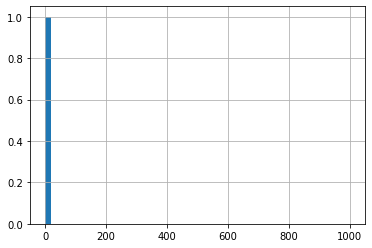

In [76]:
data['airports_nearest'].hist(range=(0,1000),bins=50);

In [77]:
data[data['airports_nearest']<50]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
21078,0,7000000.0,34.7,2018-09-23,1,270,9,19.8,3,NaN,False,False,6.0,2,Санкт-Петербург,0.0,22801.0,0.0,NaN,0.0,NaN,60.0


In [78]:
data.loc[21003, 'airports_nearest'] = np.nan
data.loc[21003]

total_images                             14
last_price                        2050000.0
total_area                             39.4
first_day_exposition    2018-02-03 00:00:00
rooms                                     1
ceiling_height                          260
floors_total                              5
living_area                            17.1
floor                                     4
is_apartment                            NaN
studio                                False
open_plan                             False
kitchen_area                            8.2
balcony                                   0
locality_name                      Волосово
airports_nearest                        NaN
cityCenters_nearest                     NaN
parks_around3000                        NaN
parks_nearest                           NaN
ponds_around3000                        NaN
ponds_nearest                           NaN
days_exposition                       312.0
Name: 21003, dtype: object

Все пропуски заполним медианами значений *airports_nearest* (если оно будет не NaN) из других строк где совпадает *locality_name*

In [79]:
# loc_median - здесь сохраним медианы расстояний по населенным пунктам

print('Медианы расстояний airports_nearest в locality_name : ')
loc_median = data.groupby('locality_name')['airports_nearest'].median().sort_values()
loc_median = loc_median.dropna()
display(loc_median.head(15))

# Функция для присваивания пропуску значения медианы
def med_insert(loc_dist):
    if loc_dist not in loc_median:
        return np.nan
    return loc_median[loc_dist]


print('Проверка работы med_insert: поселок Понтонный - ', med_insert('поселок Понтонный')) 
print('Проверка работы med_insert: поселок Усть-Ижора - ', med_insert('поселок Усть-Ижора'))

Медианы расстояний airports_nearest в locality_name : 


locality_name
поселок Александровская    12896.5
Пушкин                     15766.0
поселок Шушары             17427.0
Павловск                   20529.5
поселок Петро-Славянка     20605.0
Красное Село               25730.0
поселок Металлострой       25758.0
Колпино                    26232.0
поселок Усть-Ижора         26510.5
Санкт-Петербург            26726.0
поселок Стрельна           28317.0
поселок Понтонный          30642.0
поселок Саперный           34147.5
Петергоф                   39231.0
Ломоносов                  48415.5
Name: airports_nearest, dtype: float64

Проверка работы med_insert: поселок Понтонный -  30642.0
Проверка работы med_insert: поселок Усть-Ижора -  26510.5


In [80]:
# Выборка для проверки
print('Всего пропущенных значений в столбце =', data['airports_nearest'].isna().sum())
test_ind = data.loc[(data['locality_name']=='Санкт-Петербург') & (data['airports_nearest'].isna()==True)].index
print("Всего пропущенных значений в Санкт-Петербург =", len(test_ind))
display(data.loc[test_ind,['locality_name','airports_nearest']].head(12))

Всего пропущенных значений в столбце = 5530
Всего пропущенных значений в Санкт-Петербург = 84


,locality_name,airports_nearest
81,Санкт-Петербург,NaN
593,Санкт-Петербург,NaN
604,Санкт-Петербург,NaN
733,Санкт-Петербург,NaN
742,Санкт-Петербург,NaN
795,Санкт-Петербург,NaN
974,Санкт-Петербург,NaN
1336,Санкт-Петербург,NaN
1872,Санкт-Петербург,NaN
1895,Санкт-Петербург,NaN


In [81]:
# делаем замену
data.loc[data['airports_nearest'].isna()==True, 'airports_nearest'] = data['locality_name'].apply(med_insert)

In [82]:
# проверяем
display(data.loc[test_ind,['locality_name','airports_nearest']].head(12))

,locality_name,airports_nearest
81,Санкт-Петербург,26726.0
593,Санкт-Петербург,26726.0
604,Санкт-Петербург,26726.0
733,Санкт-Петербург,26726.0
742,Санкт-Петербург,26726.0
795,Санкт-Петербург,26726.0
974,Санкт-Петербург,26726.0
1336,Санкт-Петербург,26726.0
1872,Санкт-Петербург,26726.0
1895,Санкт-Петербург,26726.0


Проверим сколько осталось пропусков и найдем медианцу столбца

In [83]:
print("Кол-во пропусков оставшихся =", data['airports_nearest'].isna().sum())

Кол-во пропусков оставшихся = 5438


In [84]:

# print('Тип до замены', data['airports_nearest'].dtype)
# data['airports_nearest'] = data['airports_nearest'].astype(int)
# print('Тип после замены', data['airports_nearest'].dtype)

Поменять тип столбца, так как есть пропуски, не получается.

_**Вывод:**_ Осталось очень много пропусков. По-скольку для поставленных целей столбец не нужен - оставим как есть.

_**8. Столбец "cityCenters_nearest"**_

23,3% пропусков - много. Проанализируем и надо заполнить. Поменяем тип на *int*

In [85]:
data.loc[:,['cityCenters_nearest']].describe()

,cityCenters_nearest
count,18096.000000
mean,14184.814931
std,8615.094638
min,181.000000
25%,9233.000000
50%,13093.000000
75%,16287.000000
max,65968.000000


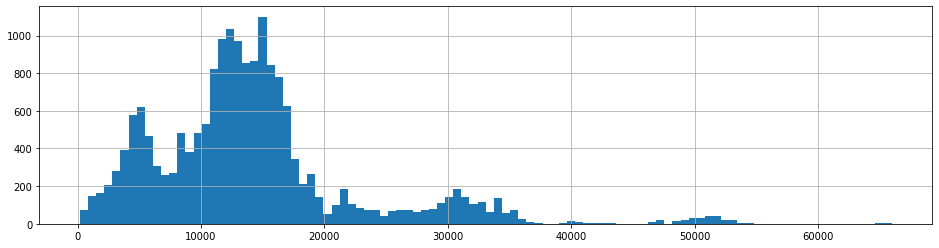

In [86]:
data['cityCenters_nearest'].hist(figsize=(16,4), bins=100);

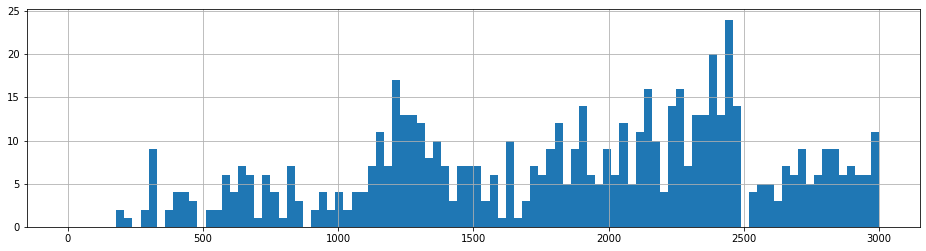

In [87]:
data['cityCenters_nearest'].hist(figsize=(16,4), bins=100, range=(0,3000));

Выбросов вроде нет, значения распределены равномерно

Займемся заполнением пропусков
Будем искать соответсткие в столбце *(locality_name)* название населённого пункта. Если населенный пункт в пропуске совпадает с другими где нет пропусков, то посчитаем среднее для тех где есть значение расстояние до центра

Все пропуски заполним медианами значений *cityCenters_nearest* (если оно будет не NaN) из других строк где совпадает *locality_name*

In [88]:
# loc_median - здесь сохрним медианы расстояний по населенным пунктам

print('Медианы расстояний cityCenters_nearest в locality_name : ')
loc_median = data.groupby('locality_name')['cityCenters_nearest'].median().sort_values()
loc_median = loc_median.dropna()
display(loc_median.head(15))

# Функция для присваивания пропуску значения медианы
def med_insert(loc_dist):
    if loc_dist not in loc_median:
        return np.nan
    return loc_median[loc_dist]


print('Проверка работы med_insert: поселок Песочный - ', med_insert('поселок Песочный')) 
print('Проверка работы med_insert: поселок Петро-Славянка - ', med_insert('поселок Петро-Славянка'))

Медианы расстояний cityCenters_nearest в locality_name : 


locality_name
Санкт-Петербург            12240.0
поселок Парголово          19311.0
поселок Стрельна           23506.0
поселок Шушары             24212.0
поселок Левашово           25727.0
поселок Песочный           26099.5
поселок Петро-Славянка     27165.0
поселок Александровская    27468.0
поселок Металлострой       27602.0
Пушкин                     27930.5
поселок Усть-Ижора         28222.5
поселок Лисий Нос          28226.0
Красное Село               29155.0
Колпино                    32018.0
поселок Понтонный          32354.0
Name: cityCenters_nearest, dtype: float64

Проверка работы med_insert: поселок Песочный -  26099.5
Проверка работы med_insert: поселок Петро-Славянка -  27165.0


In [89]:
# Выборка для проверки
print('Всего пропущенных значений в столбце =', data['cityCenters_nearest'].isna().sum())
test_ind = data.loc[(data['locality_name']=='Санкт-Петербург') & (data['cityCenters_nearest'].isna()==True)].index
print("Всего пропущенных значений в Санкт-Петербург =", len(test_ind))
display(data.loc[test_ind,['locality_name','cityCenters_nearest']].head(12))

Всего пропущенных значений в столбце = 5507
Всего пропущенных значений в Санкт-Петербург = 60


,locality_name,cityCenters_nearest
81,Санкт-Петербург,NaN
593,Санкт-Петербург,NaN
604,Санкт-Петербург,NaN
742,Санкт-Петербург,NaN
795,Санкт-Петербург,NaN
1336,Санкт-Петербург,NaN
1872,Санкт-Петербург,NaN
1895,Санкт-Петербург,NaN
2364,Санкт-Петербург,NaN
2707,Санкт-Петербург,NaN


In [90]:
# Делаем замену и проверяем
data.loc[data['cityCenters_nearest'].isna()==True, 'cityCenters_nearest'] = data['locality_name'].apply(med_insert)
display(data.loc[test_ind,['locality_name','cityCenters_nearest']].head(12))

,locality_name,cityCenters_nearest
81,Санкт-Петербург,12240.0
593,Санкт-Петербург,12240.0
604,Санкт-Петербург,12240.0
742,Санкт-Петербург,12240.0
795,Санкт-Петербург,12240.0
1336,Санкт-Петербург,12240.0
1872,Санкт-Петербург,12240.0
1895,Санкт-Петербург,12240.0
2364,Санкт-Петербург,12240.0
2707,Санкт-Петербург,12240.0


Проверим сколько осталось пропусков и найдем медианцу столбца

In [91]:
print("Кол-во пропусков оставшихся =", data['cityCenters_nearest'].isna().sum())

Кол-во пропусков оставшихся = 5438


Всего пропущенных значений было в столбце = 5517

In [92]:
print('итого было исправлено 5517 - 4870 =' , 5517 - 4870)

итого было исправлено 5517 - 4870 = 647


Всего удалось заполнить 646 строк - очень мало. Очень много пропусков.

Вернемся к данным приведенным в начале обработки столбца *airports_nearest:*

 * **airports_nearest      18157 non-null  float64**
 * **cityCenters_nearest   18180 non-null  float64**
 * **parks_around3000      18181 non-null  float64**
 *   parks_nearest         8079 non-null   float64
 * **ponds_around3000      18181 non-null  float64**
 *   ponds_nearest         9110 non-null   float64

У выделенных столбцов около 18181 значение. Проверим заполненные/пропущенные значения в одних и тех же строках?

In [93]:
# заполненные

# matches_False = data.loc[(data['airports_nearest'].isna()==False) & (data['cityCenters_nearest'].isna()==False) & \
#          (data['parks_around3000'].isna()==False) & (data['ponds_around3000'].isna()==False),'locality_name'].count()

matches_False = data.query('airports_nearest.isna()==False and cityCenters_nearest.isna()==False and \
                                parks_around3000.isna()==False and ponds_around3000.isna()==False')

print('Количество строк в которых одномременно заполненны все 4 столбца =', matches_False['locality_name'].count())

Количество строк в которых одномременно заполненны все 4 столбца = 18095


In [94]:
# пропущенные

# matches_True = data.loc[(data['airports_nearest'].isna()==True) & (data['cityCenters_nearest'].isna()==True) & \
#          (data['parks_around3000'].isna()==True) & (data['ponds_around3000'].isna()==True),'locality_name'].count()

#---- !! matches_True - сохраним для баг-репорта ------------------------------------
matches_True = data.query('airports_nearest.isna()==True and cityCenters_nearest.isna()==True and \
                                parks_around3000.isna()==True and ponds_around3000.isna()==True')

print('Количество строк в которых одномременно НЕзаполненны все 4 столбца =', matches_True['locality_name'].count())

display(matches_True.groupby('locality_name')['locality_name'].count().sort_values().tail(15))

Количество строк в которых одномременно НЕзаполненны все 4 столбца = 5430


locality_name
Никольское                  93
Тосно                      104
Кингисепп                  104
Волхов                     111
Сланцы                     112
поселок Бугры              113
Кириши                     125
Сертолово                  142
деревня Новое Девяткино    143
Кудрово                    171
Выборг                     237
деревня Кудрово            299
Гатчина                    307
Всеволожск                 398
поселок Мурино             552
Name: locality_name, dtype: int64

_**Вывод:**_ Оставшиеся пропущенные значения в столбце *cityCenters_nearest* заполнить не представляется возможным, так как если заполнить медианой или средней по всему столбцу это очень сильно может повлиять на исследовательский анализ и сильно исказить результаты и выводы. Поэтому оставим все как есть, и будем выполнять анализ с таким количеством пропусков.

p.s. В столбце airports_nearest мы наблюдали похожую картину, полагаю и в parks_around3000 и ponds_around3000 нас ждет похожая картина(благо они не представляют ценности для анализа). При таком совпадении можно сделать вывод, что пропущенные данные в этих столбцах были каким-то образом утеряны или скорее всего не внесены в таблицу, причем по конкретным пунктам - возможно прямо по каким-то областям (так как мы пробовали найти соответствие в пропущенных и заполненных населенных пунктах и его почти не было)! Данные для баг-репорта сохранили в ДатаФрейм - matches_True

In [95]:
matches_True.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
5,10,2890000.0,30.40,2018-09-10,1,265,12,14.4,5,NaN,False,False,9.1,0,поселок городского типа Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
8,20,2900000.0,33.16,2018-05-23,1,265,27,15.4,26,NaN,False,False,8.8,0,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
12,10,3890000.0,54.00,2016-06-30,2,265,5,30.0,5,NaN,False,False,9.0,0,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN,90.0
22,20,5000000.0,58.00,2017-04-24,2,275,25,30.0,15,NaN,False,False,11.0,2,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,60.0
30,12,2200000.0,32.80,2018-02-19,1,265,9,18.6,2,NaN,False,False,5.7,0,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0


_**9. Столбец "parks_around3000"**_

In [96]:
data['parks_around3000'].value_counts(dropna=False)

0.0    10060
1.0     5655
NaN     5506
2.0     1737
3.0      645
Name: parks_around3000, dtype: int64

Поскольку видно, что значение 0 это большинство и логично, что при заполнениии если значение не проставлено, то оно равно 0,- заполним пропуски 0. (Так же учтем то, что этот столбец бесполезен для выполнения задачи). И изменим тип на *int*

In [97]:
data['parks_around3000'] = data['parks_around3000'].fillna(0)
display(data['parks_around3000'].value_counts(dropna=False))
data['parks_around3000'] = data['parks_around3000'].astype(int)
print(data['parks_around3000'].dtype)

0.0    15566
1.0     5655
2.0     1737
3.0      645
Name: parks_around3000, dtype: int64

int64


_**ВЫВОД:**_ Столбец корректен.

_**10. Столбец "parks_nearest"**_

In [98]:
data.loc[:,['parks_nearest']].describe()

,parks_nearest
count,8041.000000
mean,490.589852
std,341.391138
min,1.000000
25%,288.000000
50%,455.000000
75%,612.000000
max,3190.000000


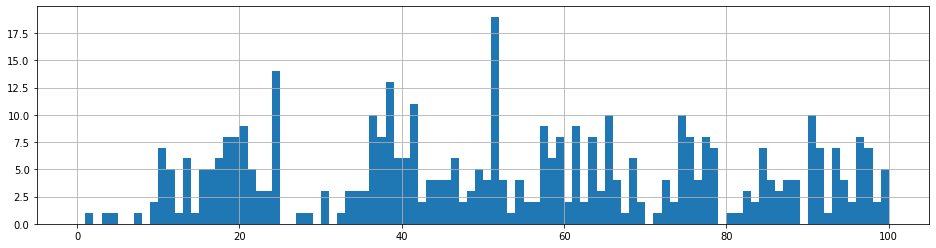

In [99]:
data['parks_nearest'].hist(figsize=(16,4), bins=100, range=(0,100));

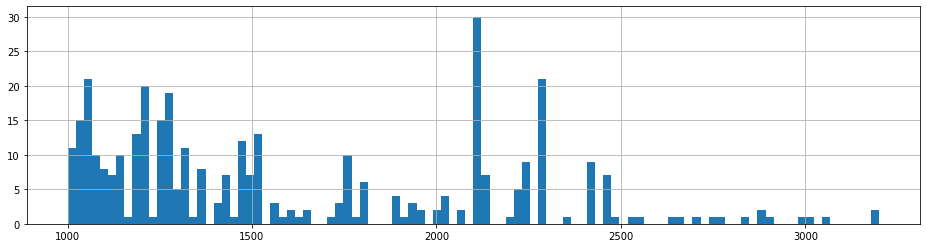

In [100]:
data['parks_nearest'].hist(figsize=(16,4), bins=100, range=(1000,3200));

Значения распределены равномерно. Большая часть меньше 3000. Удалять ничего небудем.
Будем заполнять пропуски по аналогии со столбцом *cityCenters_nearest* и *airports_nearest* по соответствию населенному пункту

In [101]:
# loc_median - здесь сохрним медианы расстояний по населенным пунктам

print('Медианы расстояний parks_nearest в locality_name : ')
loc_median = data.groupby('locality_name')['parks_nearest'].median().sort_values()
loc_median = loc_median.dropna()
display(loc_median.head(15))

# Функция для присваивания пропуску значения медианы
def med_insert(loc_dist):
    if loc_dist not in loc_median:
        return np.nan
    return loc_median[loc_dist]


print('Проверка работы med_insert: Сестрорецк - ', med_insert('Сестрорецк')) 
print('Проверка работы med_insert: поселок Зеленогорск - ', med_insert('Зеленогорск'))

Медианы расстояний parks_nearest в locality_name : 


locality_name
Зеленогорск          147.5
Кронштадт            293.0
Петергоф             294.0
Павловск             312.0
Сестрорецк           367.0
Колпино              393.0
Пушкин               399.5
Ломоносов            407.0
Красное Село         435.0
Санкт-Петербург      460.5
поселок Стрельна     700.0
поселок Парголово    733.0
Name: parks_nearest, dtype: float64

Проверка работы med_insert: Сестрорецк -  367.0
Проверка работы med_insert: поселок Зеленогорск -  147.5


In [102]:
# Выборка для проверки
print('Всего пропущенных значений в столбце =', data['parks_nearest'].isna().sum())
test_ind = data.loc[(data['locality_name']=='Санкт-Петербург') & (data['parks_nearest'].isna()==True)].index
print("Всего пропущенных значений в Санкт-Петербург =", len(test_ind))
display(data.loc[test_ind,['locality_name','parks_nearest']].head(12))

Всего пропущенных значений в столбце = 15562
Всего пропущенных значений в Санкт-Петербург = 8420


,locality_name,parks_nearest
7,Санкт-Петербург,NaN
9,Санкт-Петербург,NaN
17,Санкт-Петербург,NaN
19,Санкт-Петербург,NaN
25,Санкт-Петербург,NaN
26,Санкт-Петербург,NaN
31,Санкт-Петербург,NaN
32,Санкт-Петербург,NaN
34,Санкт-Петербург,NaN
35,Санкт-Петербург,NaN


In [103]:
# делаем замену и проверяем
data.loc[data['parks_nearest'].isna()==True, 'parks_nearest'] = data['locality_name'].apply(med_insert)
display(data.loc[test_ind,['locality_name','parks_nearest']].head(12))

,locality_name,parks_nearest
7,Санкт-Петербург,460.5
9,Санкт-Петербург,460.5
17,Санкт-Петербург,460.5
19,Санкт-Петербург,460.5
25,Санкт-Петербург,460.5
26,Санкт-Петербург,460.5
31,Санкт-Петербург,460.5
32,Санкт-Петербург,460.5
34,Санкт-Петербург,460.5
35,Санкт-Петербург,460.5


In [104]:
print("Кол-во пропусков оставшихся =", data['parks_nearest'].isna().sum())

Кол-во пропусков оставшихся = 5994


_**ВЫВОД:**_ было пропусков 15614 осталось 6007 - большую часть значений заполнили, теперь со значениями около 18 тысяч.
Остальные не заполняем по аналогии с другими столбцами с расстояниями

_**11. Столбец "ponds_around3000"**_

In [105]:
data['ponds_around3000'].value_counts(dropna=False)

0.0    9041
1.0    5676
NaN    5506
2.0    1884
3.0    1496
Name: ponds_around3000, dtype: int64

Все сделаем по аналогии состолбцом *parks_around3000*

In [106]:
data['ponds_around3000'] = data['ponds_around3000'].fillna(0)
display(data['ponds_around3000'].value_counts(dropna=False))
data['ponds_around3000'] = data['ponds_around3000'].astype(int)
print(data['ponds_around3000'].dtype)

0.0    14547
1.0     5676
2.0     1884
3.0     1496
Name: ponds_around3000, dtype: int64

int64


_**Вывод:**_ Столбец корректен.

_**11. Столбец "ponds_nearest"**_

In [107]:
data.loc[:,['ponds_nearest']].describe()

,ponds_nearest
count,9056.000000
mean,518.334143
std,277.865514
min,13.000000
25%,294.000000
50%,503.000000
75%,730.000000
max,1344.000000


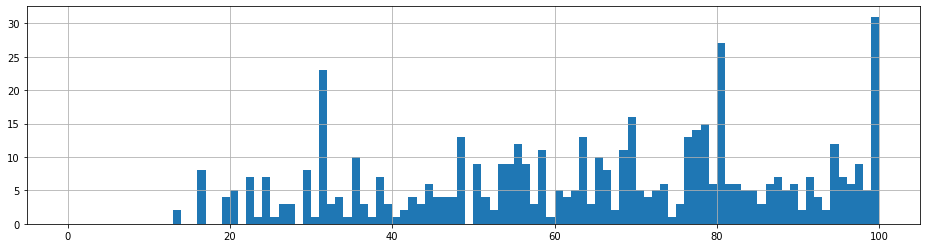

In [108]:
data['ponds_nearest'].hist(figsize=(16,4), bins=100, range=(0,100));

Выбросов вообще нет

Заполняем по аналогии с *airports_nearest , cityCenters_nearest* и *parks_nearest*

In [109]:
# loc_median - здесь сохрним медианы расстояний по населенным пунктам

print('Медианы расстояний ponds_nearest в locality_name : ')
loc_median = data.groupby('locality_name')['ponds_nearest'].median().sort_values()
loc_median = loc_median.dropna()
display(loc_median.head(15))

# Функция для присваивания пропуску значения медианы
def med_insert(loc_dist):
    if loc_dist not in loc_median:
        return np.nan
    return loc_median[loc_dist]


print('Проверка работы med_insert: Сестрорецк - ', med_insert('Сестрорецк')) 
print('Проверка работы med_insert: поселок Зеленогорск - ', med_insert('Зеленогорск'))

Медианы расстояний ponds_nearest в locality_name : 


locality_name
Красное Село          225.5
Кронштадт             312.0
поселок Белоостров    320.0
Сестрорецк            372.0
поселок Саперный      419.5
Пушкин                444.0
Павловск              458.0
Петергоф              474.0
Санкт-Петербург       504.0
Зеленогорск           507.0
Колпино               509.0
Ломоносов             553.0
поселок Шушары        584.5
поселок Парголово     593.0
поселок Понтонный     638.0
Name: ponds_nearest, dtype: float64

Проверка работы med_insert: Сестрорецк -  372.0
Проверка работы med_insert: поселок Зеленогорск -  507.0


In [110]:
# Выборка для проверки
print('Всего пропущенных значений в столбце =', data['ponds_nearest'].isna().sum())
test_ind = data.loc[(data['locality_name']=='Санкт-Петербург') & (data['ponds_nearest'].isna()==True)].index
print("Всего пропущенных значений в Санкт-Петербург =", len(test_ind))
display(data.loc[test_ind,['locality_name','ponds_nearest']].head(12))

Всего пропущенных значений в столбце = 14547
Всего пропущенных значений в Санкт-Петербург = 7726


,locality_name,ponds_nearest
7,Санкт-Петербург,NaN
9,Санкт-Петербург,NaN
16,Санкт-Петербург,NaN
18,Санкт-Петербург,NaN
19,Санкт-Петербург,NaN
21,Санкт-Петербург,NaN
31,Санкт-Петербург,NaN
34,Санкт-Петербург,NaN
36,Санкт-Петербург,NaN
45,Санкт-Петербург,NaN


In [111]:
# делаем замену и проверяем
data.loc[data['ponds_nearest'].isna()==True, 'ponds_nearest'] = data['locality_name'].apply(med_insert)
display(data.loc[test_ind,['locality_name','ponds_nearest']].head(12))

,locality_name,ponds_nearest
7,Санкт-Петербург,504.0
9,Санкт-Петербург,504.0
16,Санкт-Петербург,504.0
18,Санкт-Петербург,504.0
19,Санкт-Петербург,504.0
21,Санкт-Петербург,504.0
31,Санкт-Петербург,504.0
34,Санкт-Петербург,504.0
36,Санкт-Петербург,504.0
45,Санкт-Петербург,504.0


In [112]:
print("Кол-во пропусков оставшихся =", data['parks_nearest'].isna().sum())

Кол-во пропусков оставшихся = 5994


_**Вывод:**_ было пропусков 14584 осталось 6007 - большую часть значений заполнили, теперь со значениями около 18 тысяч.
Остальные не заполняем по аналогии с другими столбцами с расстояниями

_**12. Столбец "days_exposition"**_

13,4% пропусков - много. Нужен анализ и потом заполнить

In [113]:
data.loc[:,['days_exposition']].describe()

,days_exposition
count,20431.000000
mean,180.881161
std,219.706903
min,1.000000
25%,45.000000
50%,95.000000
75%,232.000000
max,1580.000000


Пропуски в данных говорят о том, что объявления все еще актуальны.
Смотрим, что не так с объявлениями, которые размещены более 1000 дней.

In [114]:
data[data['days_exposition'] > 1000].sample(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
7024,1,21453004.0,156.4,2014-11-27,4,265,13,88.7,13,NaN,False,False,27.0,0,Санкт-Петербург,29990.0,4870.0,1,641.0,1,145.0,1214.0
20628,10,4600000.0,44.0,2014-11-27,1,265,22,20.0,19,NaN,False,False,10.0,1,Санкт-Петербург,15268.0,13377.0,0,460.5,1,636.0,1002.0
1564,2,9950000.0,71.0,2015-08-23,2,300,8,35.6,1,NaN,False,False,16.1,0,Санкт-Петербург,39384.0,11087.0,1,471.0,0,504.0,1095.0
4343,9,7100000.0,54.0,2015-05-29,2,260,14,30.0,12,NaN,False,False,15.0,0,Санкт-Петербург,14762.0,13558.0,0,460.5,0,504.0,1199.0
12959,3,9847530.0,69.3,2015-10-02,2,273,20,33.6,10,False,False,False,15.3,0,Санкт-Петербург,39140.0,10364.0,2,173.0,3,196.0,1048.0
1885,2,13300000.0,79.6,2014-12-09,2,300,8,42.7,7,NaN,False,False,18.0,0,Санкт-Петербург,39393.0,11096.0,1,537.0,0,504.0,1513.0
18788,12,3700000.0,63.0,2016-05-30,3,250,12,46.0,5,NaN,False,False,6.5,0,поселок Бугры,NaN,NaN,0,NaN,0,NaN,1050.0
2175,8,23990000.0,153.0,2015-12-18,4,280,25,75.0,12,NaN,False,False,40.0,0,Санкт-Петербург,51333.0,13056.0,0,460.5,0,504.0,1179.0
6926,3,16177174.0,122.7,2015-12-14,3,300,19,45.9,4,NaN,False,False,10.2,0,Санкт-Петербург,18748.0,4341.0,0,460.5,0,504.0,1175.0
11753,6,5830007.0,88.9,2015-03-10,3,270,21,49.9,10,NaN,False,False,14.7,0,Санкт-Петербург,21793.0,17121.0,0,460.5,1,31.0,1099.0


Не очень очевидно, но видно, что это одни из самых первых объявлений (2014 -2015 гг.). Причины связаны с человеческим фактором:
Обьявления не были удалены после продажи,
Цена сильно завышена, но продавец продалжает ждать своего покупателя,
и так далее.

In [115]:
import numpy as np
data['days_exposition'] = np.floor(pd.to_numeric(data['days_exposition'], errors='coerce')).astype('Int64')

Столбец скорректирован

_**Поиск дубликатов**_

Для идентификации дубликатов возьмем совпадения по нескольким столбцам - по тем в которых быди все значения изначально и особенно в которых маловероятны совпадения: 1) *first_day_exposition* (++ его почти не меняли и много разных дат), 2) *last_price*(++здесь должно быть мало повторении), 3) *total_area* 4) *total_images* (вообще не меняли) - этого достаточно.

In [116]:
dupl2 = data[data[['total_images', 'last_price','first_day_exposition','total_area']].duplicated(keep=False)]
dupl2.sort_values(by='total_images')
print('Первоначальная')
display(dupl1.sort_values(by='first_day_exposition'))
print()
print('Измененная')
display(dupl2.sort_values(by='first_day_exposition'))

Первоначальная


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
19052,3,4370000.0,38.00,2016-06-23T00:00:00,1,NaN,9.0,19.5,1,NaN,False,False,NaN,NaN,Санкт-Петербург,27103.0,7640.0,1.0,624.0,0.0,NaN,620.0
19325,3,4370000.0,38.00,2016-06-23T00:00:00,1,NaN,9.0,NaN,2,NaN,False,False,NaN,NaN,Санкт-Петербург,27103.0,7640.0,1.0,624.0,0.0,NaN,620.0
9661,1,2533531.0,42.50,2016-09-08T00:00:00,1,2.56,18.0,19.8,7,False,False,False,NaN,NaN,Никольское,NaN,NaN,NaN,NaN,NaN,NaN,627.0
18425,1,2533531.0,42.50,2016-09-08T00:00:00,1,2.56,18.0,20.0,10,False,False,False,NaN,NaN,Никольское,NaN,NaN,NaN,NaN,NaN,NaN,627.0
10099,10,4400000.0,44.00,2017-11-22T00:00:00,1,NaN,17.0,17.0,14,NaN,False,False,13.0,2.0,Санкт-Петербург,42901.0,9267.0,0.0,NaN,0.0,NaN,71.0
21142,10,4400000.0,44.00,2017-11-22T00:00:00,2,NaN,9.0,27.0,8,NaN,False,False,6.0,1.0,Санкт-Петербург,49917.0,16755.0,1.0,235.0,0.0,NaN,72.0
14739,10,5142565.0,54.65,2018-10-01T00:00:00,2,NaN,5.0,26.0,3,NaN,False,False,NaN,NaN,Санкт-Петербург,47303.0,25866.0,1.0,251.0,1.0,350.0,145.0
18624,10,5142565.0,54.65,2018-10-01T00:00:00,2,NaN,5.0,26.0,5,NaN,False,False,NaN,NaN,Санкт-Петербург,47303.0,25866.0,1.0,251.0,1.0,350.0,145.0



Измененная


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
19045,3,4370000.0,38.00,2016-06-23,1,265,9,19.5,1,NaN,False,False,6.5,0,Санкт-Петербург,27103.0,7640.0,1,624.0,0,504.0,620
19318,3,4370000.0,38.00,2016-06-23,1,265,9,21.6,2,NaN,False,False,6.5,0,Санкт-Петербург,27103.0,7640.0,1,624.0,0,504.0,620
9658,1,2533531.0,42.50,2016-09-08,1,256,18,19.8,7,False,False,False,7.3,0,Никольское,NaN,NaN,0,NaN,0,NaN,627
18418,1,2533531.0,42.50,2016-09-08,1,256,18,20.0,10,False,False,False,7.3,0,Никольское,NaN,NaN,0,NaN,0,NaN,627
10096,10,4400000.0,44.00,2017-11-22,1,265,17,17.0,14,NaN,False,False,13.0,2,Санкт-Петербург,42901.0,9267.0,0,460.5,0,504.0,71
21135,10,4400000.0,44.00,2017-11-22,2,265,9,27.0,8,NaN,False,False,6.0,1,Санкт-Петербург,49917.0,16755.0,1,235.0,0,504.0,72
14736,10,5142565.0,54.65,2018-10-01,2,265,5,26.0,3,NaN,False,False,9.4,0,Санкт-Петербург,47303.0,25866.0,1,251.0,1,350.0,145
18617,10,5142565.0,54.65,2018-10-01,2,265,5,26.0,5,NaN,False,False,9.4,0,Санкт-Петербург,47303.0,25866.0,1,251.0,1,350.0,145


Пары дубликатов:

* (индексы 19045 и 19318) отличаются только этажом (наверно указан был неправильно) - удалим 19318
* (индексы 9658 и 18418) отличаются этажом, а площадь почти одинаковая 19,8 и 20 - удалим 18418
* (индексы 10096 и 21135) много отличий будем считать, что это разные квартиры
* (индексы 14736 и 18617) отличаются только этажом (наверно указан был неправильно) - удалим 18624

In [117]:
print("Кол-во строк до удаления",len(data))
data.drop([19318,18418,18624], axis=0, inplace=True)
print("Кол-во строк после удаления",len(data))

Кол-во строк до удаления 23603
Кол-во строк после удаления 23600


In [118]:
data.reset_index(drop=True, inplace=True)
display(data)
data.info()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07,3,270,16,51.0,8,NaN,False,False,25.0,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,<NA>
1,7,3350000.0,40.40,2018-12-04,1,265,11,18.6,1,NaN,False,False,11.0,2,поселок Шушары,12817.0,18603.0,0,NaN,0,584.5,81
2,10,5196000.0,56.00,2015-08-20,2,265,5,34.3,4,NaN,False,False,8.3,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558
3,0,64900000.0,159.00,2015-07-24,3,265,14,90.2,9,NaN,False,False,27.4,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424
4,2,10000000.0,100.00,2018-06-19,2,303,14,32.0,13,NaN,False,False,40.0,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23595,9,9700000.0,133.81,2017-03-21,3,370,5,73.3,3,NaN,False,False,13.8,0,Санкт-Петербург,24665.0,4232.0,1,796.0,3,381.0,<NA>
23596,14,3100000.0,59.00,2018-01-15,3,265,5,38.0,4,NaN,False,False,8.5,0,Тосно,NaN,NaN,0,NaN,0,NaN,45
23597,18,2500000.0,56.70,2018-02-11,2,265,3,29.7,1,NaN,False,False,9.8,0,село Рождествено,NaN,NaN,0,NaN,0,NaN,<NA>
23598,13,11475000.0,76.75,2017-03-28,2,300,17,43.5,12,NaN,False,False,23.3,2,Санкт-Петербург,39140.0,10364.0,2,173.0,3,196.0,602


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23600 entries, 0 to 23599
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23600 non-null  int64         
 1   last_price            23600 non-null  float64       
 2   total_area            23600 non-null  float64       
 3   first_day_exposition  23600 non-null  datetime64[ns]
 4   rooms                 23600 non-null  int64         
 5   ceiling_height        23600 non-null  int64         
 6   floors_total          23600 non-null  int64         
 7   living_area           23600 non-null  float64       
 8   floor                 23600 non-null  int64         
 9   is_apartment          2772 non-null   object        
 10  studio                23600 non-null  bool          
 11  open_plan             23600 non-null  bool          
 12  kitchen_area          23454 non-null  float64       
 13  balcony         

_**Общий вывод:**_

Удалено 0,27% данных - вполне хорошо.

* столбец *first_day_exposition* приведен к типу *datetime64*
* В столбце *ceiling_height* заменили большую часть на медиану. Здесь были обнаружены ошибочно введенные значения, в которых справа присутствовал лишний ноль,- исправили
* В столбцах *living_area и kitchen_area* произведена взаимосвязанная заменя медианами. Так же учтены квартиры студии, - в строках где студии в столбце *kitchen_area* оставлено *NaN*.
* В числовых столбцах заменены типы на *int*, кроме столбцов с площадями(округлено до 0,1), и столбцов с расстояниями (оставили *float* - здесь мрого пропусков)
* В столбцах с расстояниями заменяли пропуски средними значениями по каждому населенному пункту (удалось заполнить совсем мало значений) и при обработке было выясненно , что полностью невозможно заполнить столбцы с расстояниями: *airports_nearest*, *parks_nearest*, ponds_nearest и особенно важный *cityCenters_nearest*. Единственная возможность заполнить пропуски в них - заполнить средней или медианой всего столбца - но в таком случае при решении задач дальнейшего анализа это сильно может исказить результат. Поэтому при анализе, там где будет затронут столбец *cityCenters_nearest*, будем довольствоваться строками, где присутствуют значения в этом столбце.
* В ДатаФрейм *"matches_True"* - сохранены строки в которых пропуски в расстояниях(Баг-Репорт)
* Столбцы *days_exposition* и 4 столбца с расстояниями заполнялись по одинаковому алгоритму.

# Добавление в таблицу новых столбцов

_**Для дальнейшего анализа необходимо добавить:**_

* цена одного квадратного метра (нужно поделить стоимость объекта на его общую площадь, а затем округлить до двух знаков после запятой);
* день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
* месяц публикации объявления;
* год публикации объявления;
* тип этажа квартиры (значения — «‎первый», «последний», «другой»);
* расстояние до центра города в километрах (переведите из м в км и округлите до ближайших целых значений).

**Цена квадратного метра**

In [119]:
data['sq_metr_pr'] = data['last_price'] / data['total_area']
data['sq_metr_pr'] = data['sq_metr_pr'].astype(int)
display(data['sq_metr_pr'].sample(3))
display(data.sample(3))
data['sq_metr_pr'].dtype

7647     79545
5020    134934
1603    105000
Name: sq_metr_pr, dtype: int64

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sq_metr_pr
13960,5,4400000.0,62.3,2019-01-10,3,250,9,35.3,7,NaN,False,False,10.7,0,Санкт-Петербург,19309.0,18312.0,1,766.0,1,329.0,19,70626
18314,4,1400000.0,31.5,2018-03-17,1,254,5,17.4,4,NaN,False,False,5.4,1,Приозерск,NaN,NaN,0,NaN,0,NaN,133,44444
19298,9,20786000.0,109.0,2018-07-16,2,300,7,61.8,4,NaN,False,False,40.0,0,Санкт-Петербург,24283.0,4850.0,2,335.0,0,504.0,5,190697


dtype('int64')

**День недели, месяц и год публикации объявления**

In [120]:
data['day_exp'] = data['first_day_exposition'].dt.weekday
data['month_exp'] = data['first_day_exposition'].dt.month
data['year_exp'] = data['first_day_exposition'].dt.year
display(data[['day_exp', 'month_exp', 'year_exp']].sample(8))
display(data.sample(3))

,day_exp,month_exp,year_exp
3994,5,6,2018
21752,3,2,2018
22055,2,1,2018
20227,6,4,2017
22155,1,5,2018
8608,2,10,2018
12378,0,11,2018
13264,4,9,2017


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sq_metr_pr,day_exp,month_exp,year_exp
17327,17,9450000.0,98.0,2017-03-03,3,320,4,59.2,4,NaN,False,False,13.0,0,Санкт-Петербург,9859.0,13105.0,1,107.0,1,510.0,510,96428,4,3,2017
10474,0,17200000.0,60.0,2018-01-01,1,265,6,34.0,2,NaN,False,False,10.3,0,Санкт-Петербург,32859.0,5951.0,1,784.0,3,103.0,76,286666,0,1,2018
2827,1,2250000.0,55.0,2018-01-12,2,265,5,31.2,3,NaN,False,False,9.5,0,Кингисепп,NaN,NaN,0,NaN,0,NaN,45,40909,4,1,2018


**Этаж квартиры; варианты — первый, последний, другой (firtst, last, other)**

In [121]:
# data['cat_floor'] = 'other'
# # data['cat_floor'] = data['floor'].where(data['floor']==1,'firtst', 'other')
# # data['cat_floor'] = data['floor'].where(data['floor']==1, 'other')

data['cat_floor'] = np.nan # Новый столбец - категории этажа: первый, последний, другой 

def floor_insert(row):
    if row['floor']==1:
        return 'первый'
    elif row['floor']==row['floors_total']:
        return 'последний'
    else:
        return 'другой'

data['cat_floor'] = data.apply(floor_insert, axis=1)

print(data['cat_floor'].value_counts(dropna=False))

другой       17353
последний     3335
первый        2912
Name: cat_floor, dtype: int64


**Cоотношение жилой и общей площади, а также отношение площади кухни к общей.**

In [122]:
data['liv_tot'] = round(data['kitchen_area'] / data['total_area'],2)
data['kit_tot'] = round(data['kitchen_area'] / data['total_area'],2)
display(data[['liv_tot', 'kit_tot']])

,liv_tot,kit_tot
0,0.23,0.23
1,0.27,0.27
2,0.15,0.15
3,0.17,0.17
4,0.40,0.40
...,...,...
23595,0.10,0.10
23596,0.14,0.14
23597,0.17,0.17
23598,0.30,0.30


_**Данные о расстоянии до центра города city_centers_nearest**_

In [123]:
#переводим расстояние до центра города в км и отбрасываем дробную часть
data['cityCenters_km'] = data['cityCenters_nearest']/1000
data['cityCenters_km'] = round(data['cityCenters_km'])
data.loc[:,['cityCenters_km']].describe()


,cityCenters_km
count,18163.000000
mean,14.180477
std,8.620319
min,0.000000
25%,9.000000
50%,13.000000
75%,16.000000
max,66.000000


In [124]:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sq_metr_pr,day_exp,month_exp,year_exp,cat_floor,liv_tot,kit_tot,cityCenters_km
0,20,13000000.0,108.00,2019-03-07,3,270,16,51.0,8,NaN,False,False,25.0,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,<NA>,120370,3,3,2019,другой,0.23,0.23,16.0
1,7,3350000.0,40.40,2018-12-04,1,265,11,18.6,1,NaN,False,False,11.0,2,поселок Шушары,12817.0,18603.0,0,NaN,0,584.5,81,82920,1,12,2018,первый,0.27,0.27,19.0
2,10,5196000.0,56.00,2015-08-20,2,265,5,34.3,4,NaN,False,False,8.3,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558,92785,3,8,2015,другой,0.15,0.15,14.0
3,0,64900000.0,159.00,2015-07-24,3,265,14,90.2,9,NaN,False,False,27.4,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424,408176,4,7,2015,другой,0.17,0.17,7.0
4,2,10000000.0,100.00,2018-06-19,2,303,14,32.0,13,NaN,False,False,40.0,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121,100000,1,6,2018,другой,0.40,0.40,8.0
5,10,2890000.0,30.40,2018-09-10,1,265,12,14.4,5,NaN,False,False,9.1,0,поселок городского типа Янино-1,NaN,NaN,0,NaN,0,NaN,55,95065,0,9,2018,другой,0.30,0.30,NaN
6,6,3700000.0,37.30,2017-11-02,1,265,26,14.9,6,NaN,False,False,14.4,1,поселок Парголово,52996.0,19143.0,0,733.0,0,593.0,155,99195,3,11,2017,другой,0.39,0.39,19.0
7,5,7915000.0,71.60,2019-04-18,2,265,24,40.6,22,NaN,False,False,18.9,2,Санкт-Петербург,23982.0,11634.0,0,460.5,0,504.0,<NA>,110544,3,4,2019,другой,0.26,0.26,12.0
8,20,2900000.0,33.16,2018-05-23,1,265,27,15.4,26,NaN,False,False,8.8,0,поселок Мурино,NaN,NaN,0,NaN,0,NaN,189,87454,2,5,2018,другой,0.27,0.27,NaN
9,18,5400000.0,61.00,2017-02-26,3,250,9,43.6,7,NaN,False,False,6.5,2,Санкт-Петербург,50898.0,15008.0,0,460.5,0,504.0,289,88524,6,2,2017,другой,0.11,0.11,15.0


In [125]:
print(data['cityCenters_km'].isna().sum()) 

5437


Пропусков много, но икать такие данные вручную очень времязатратно, посмотрим с теми цифрами, что имеем

_**Вывод: добавленно полностью заполненных 7 столбцов**_

#  Исследовательский анализ данных

_**Изучение параметров:**_
* общая площадь;
* жилая площадь;
* площадь кухни;
* цена объекта;
* количество комнат;
* высота потолков;
* тип этажа квартиры («первый», «последний», «другой»);
* общее количество этажей в доме;
* расстояние до центра города в метрах;
* расстояние до ближайшего парка.
_**Построение гистограммы для каждого параметра.**_

**Площадь total_area**

In [126]:
data.loc[:,['total_area']].describe()

,total_area
count,23600.000000
mean,60.348294
std,35.656237
min,12.000000
25%,40.000000
50%,52.000000
75%,69.825000
max,900.000000


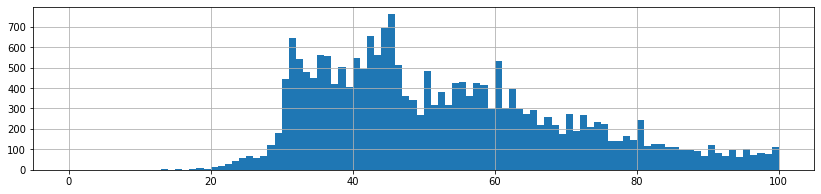

In [127]:
data['total_area'].hist(range=(0,100),figsize=(14,3), bins=100);

* Больше всего квартир с площадями 30-46 кв.м - это, похоже, самые популярные 1 и 2-х комнатные. Далее идут скорее всего 2 и 3 комнатные с площадью до 75 кв.м. Ну кол-во с большими площадами, начинает обратнопропорционально убывать - чем больше площадь, тем квартир меньше. Также видно, что квартиры сильно меньше 30 кв.м тоже довольно редки.

**Жилая площадь**

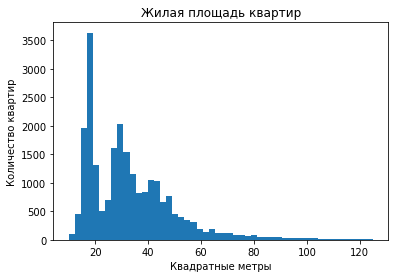

In [128]:
plt.hist(data['living_area'], bins=50, range=(10,125))
plt.title('Жилая площадь квартир')
plt.xlabel('Квадратные метры')
plt.ylabel('Количество квартир')
plt.show()

Жилая площадь имеет два пика в 20 и 30 м. Возможно вводимые данные округлялись для "красоты". Так в объявлении могли указать 20 м при реальной цифре от 17 до 20,5 м.

**площадь кухни kitchen_area**

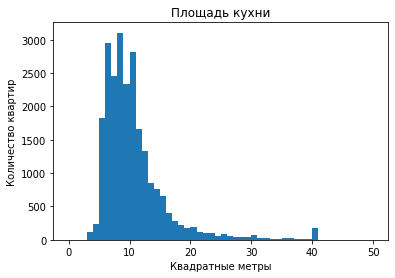

In [129]:
plt.hist(data['kitchen_area'], bins=50, range=(0,50))
plt.title('Площадь кухни')
plt.xlabel('Квадратные метры')
plt.ylabel('Количество квартир')
plt.show()

Площадь кухонь преимущественно от 5  до 12 м

**цена - last_price**

In [130]:
data.loc[:,['last_price']].describe()

,last_price
count,2.360000e+04
mean,6.541323e+06
std,1.090441e+07
min,1.219000e+04
25%,3.400000e+06
50%,4.650000e+06
75%,6.799250e+06
max,7.630000e+08


Тут можно разделить все значения на 1 млн, чтобы они пришли в более опрятный вид.

In [131]:
data['last_price'] = data['last_price']/1000000

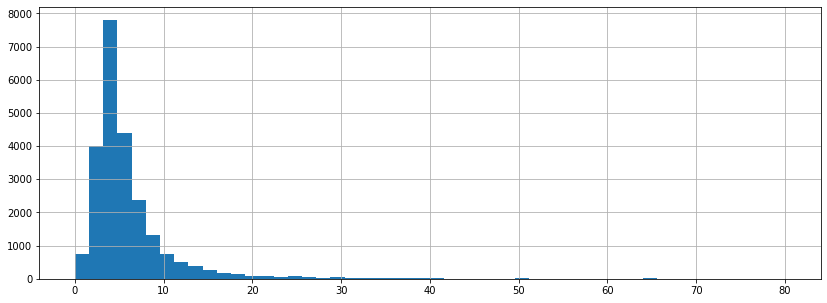

In [132]:
data['last_price'].hist(range=(0,80),figsize=(14,5), bins=50);

* Можно сделать вывод, что больше всего квартир продаются по цене в диапазоне 1,8-7,5 млн.руб. Пик же продажи квартир идет в по цене около 3,8 мнн. А в остальных случаях чем ниже и чем выше цена интерес пропорционально падает. (Распределение более похоже на распределение Пуассона

**число комнат - rooms**

In [133]:
data.loc[:,['rooms']].describe()


,rooms
count,23600.000000
mean,2.071441
std,1.078502
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,19.000000


<AxesSubplot:>

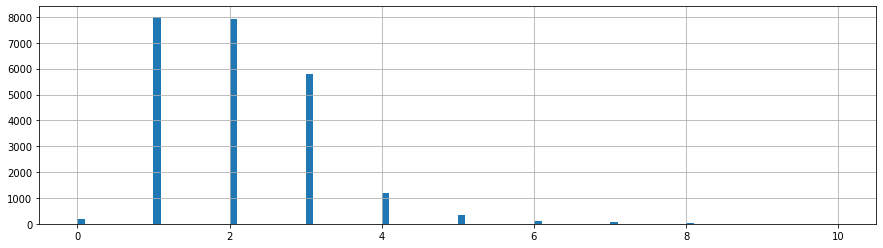

In [134]:
data['rooms'].hist(range=(0,10),figsize=(15,4), bins=100,)


Cамые популярные квартиры - 1комнатная(чуть больше 8000) и 2комнатные(около 8000). 3комнатных тоже довольно много - чуть меньше 6000, ну а дальше кол-во сильно сокращаетя. Ясно видна зависимость - чем больше комнат, тем меньше таких квартир.

**высота потолков - ceiling_height**

In [135]:
data.loc[:,['ceiling_height']].describe()

,ceiling_height
count,23600.000000
mean,269.655169
std,22.186692
min,200.000000
25%,260.000000
50%,265.000000
75%,270.000000
max,600.000000


<AxesSubplot:>

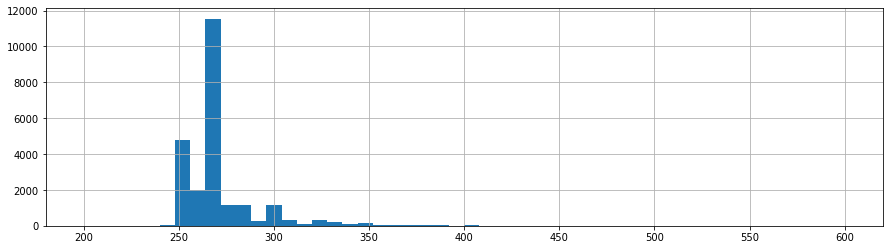

In [136]:
data['ceiling_height'].hist(range=(200,600),figsize=(15,4), bins=50,)

_**Вывод**_ Больше всего квартир с высотой потолков 250 - 300 см, подавляющее большинство почти половина с высотой 265 см. Остальные высоты довольно редки - нестандартный размер и чем выше тем это наибольшая редкость. А высоты ниже нормального диапазона тоже редкость, потому что уже такие дома не строят или там просто уменьшен потолок (подвесные, натяжные потолки и т.д.).

**тип этажа квартиры («первый», «последний», «другой»)**

In [137]:

print(data['cat_floor'].value_counts(dropna=False))

другой       17353
последний     3335
первый        2912
Name: cat_floor, dtype: int64


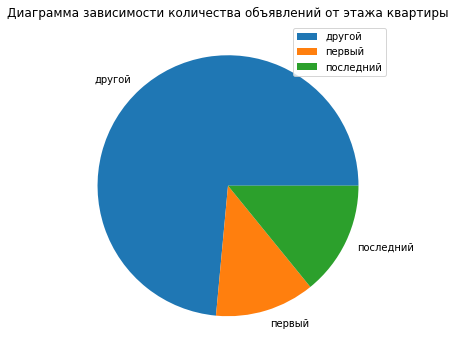

In [138]:
data.pivot_table(index='cat_floor',values='last_price',aggfunc='count') \
  .plot.pie(y='last_price', figsize=(8,6), label='', title='Диаграмма зависимости количества объявлений от этажа квартиры')

plt.show()

Квартир на первом и последнем этаже - самые не популярные. 

**общее количество этажей в доме floors_total**

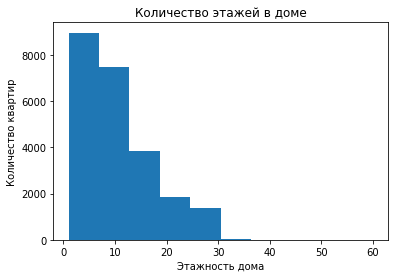

In [139]:
plt.hist(data['floors_total'], bins=10)
plt.title('Количество этажей в доме')
plt.xlabel('Этажность дома')
plt.ylabel('Количество квартир')
plt.show()

Этажность домов имеет обратно пропорциональную зависимость: чем высотнее здание, тем меньше квартир на продажу в них встречается. Преимущественно квартиры сосредоточены в 5этажных домах.

**Расстояние до центра города**

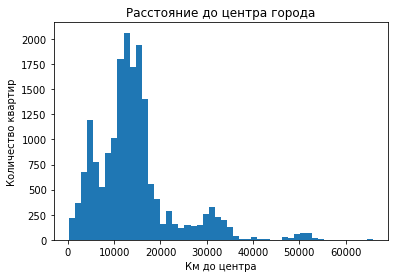

In [140]:
plt.hist(data['cityCenters_nearest'], bins=50)
plt.title('Расстояние до центра города')
plt.xlabel('Км до центра')
plt.ylabel('Количество квартир')
plt.show()

Основная масса квартир сосредочена в радиусе  5-20 км от центра города

**Расстояние до ближайшего парка**

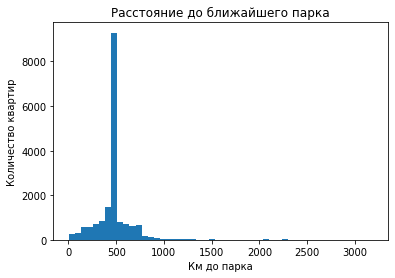

In [141]:
plt.hist(data['parks_nearest'], bins=50)
plt.title('Расстояние до ближайшего парка')
plt.xlabel('Км до парка')
plt.ylabel('Количество квартир')
plt.show()

Парки в основной массе находятся в пешей доступности до 1 км.

_**Изучим время продажи квартиры.**_

In [142]:
data.loc[:,['days_exposition']].describe()

,days_exposition
count,20428.000000
mean,180.845947
std,219.676311
min,1.000000
25%,45.000000
50%,95.000000
75%,232.000000
max,1580.000000


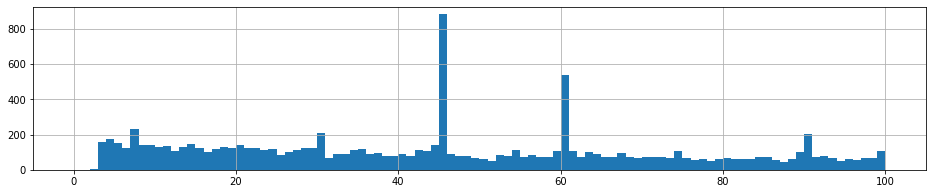

In [143]:
data['days_exposition'].hist(range=(0,100),figsize=(16,3), bins=100);

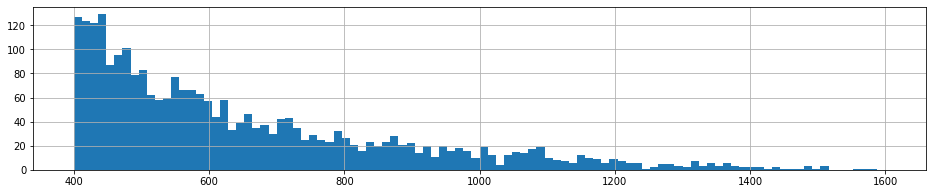

In [144]:
data['days_exposition'].hist(range=(400,1600),figsize=(16,3), bins=100);

In [145]:
print('Медиана =', data['days_exposition'].median())
print('Средняя =', data['days_exposition'].mean())

Медиана = 95.0
Средняя = 180.84594673976895


_**Вывод:**_ Из приведенных значений можно сделать вывод, что продажа квартиры занимает от 3 до 6 месяцев. Все что продается раньше 40 дней можно назвать быстрой продажей. Необычайно долгие продажи начинаются от 2 лет (нижняя гистограмма)

**Изучим, какие факторы больше всего влияют на стоимость квартиры, зависит ли цена от площади, числа комнат, удалённости от центра. Также от того, на каком этаже расположена квартира: первом, последнем или другом и от даты размещения: дня недели, месяца и года.**

* Зависимость Цены от Площади

Корелляция цены от total_area 0.6536305718404206


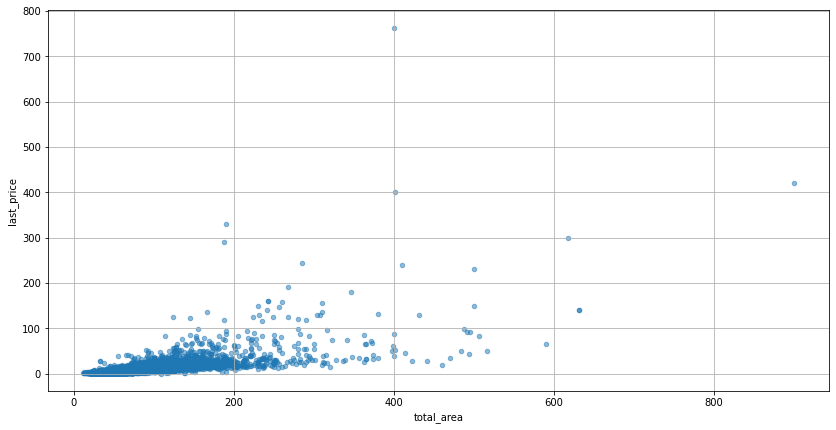

In [146]:
def corr1(column):
    print('Корелляция цены от',column , data['last_price'].corr(data[column]))
    data.plot(x=column, y='last_price', kind='scatter', grid=True, figsize=(14,7), alpha=0.5);

corr1('total_area')

Зависимость цены от площади есть, но не такая уж сильная. При возрастании площади и цена возрастает

Корреляция цены и жилой площади: 0.5875500985005165


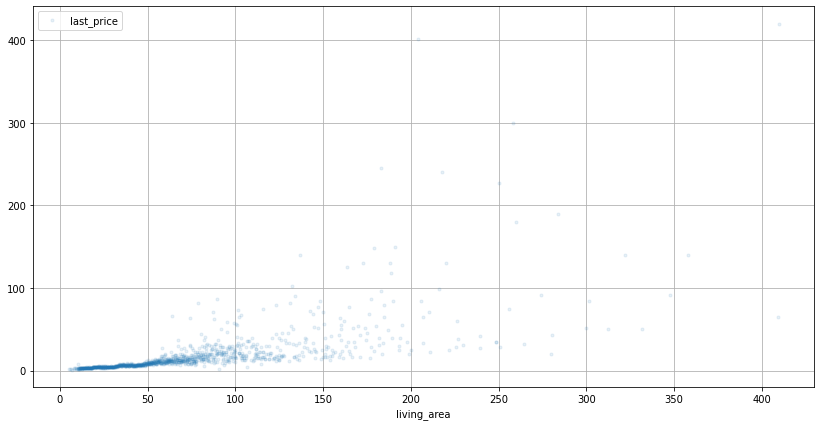

In [147]:
# Зависимость цены от жилой площади
data.pivot_table(index='living_area', values='last_price').plot(grid=True, style='o', figsize=(14, 7),alpha = 0.1, markersize=3)
print('Корреляция цены и жилой площади:', data['living_area'].corr(data['last_price']))

Зависимость цены от жилой площади еще меньше, чем в предыдущих наболюдениях. Сильно ничего не поменялось.

Корреляция цены и площади кухни: 0.46752915672310646


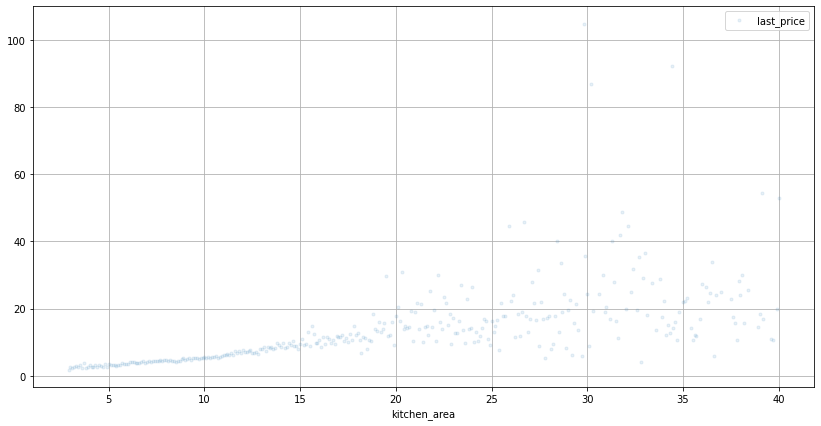

In [148]:
# Зависимость цены от площади кухни
data.pivot_table(index='kitchen_area', values='last_price').plot(grid=True, style='o', figsize=(14, 7),alpha = 0.1,markersize=3)
print('Корреляция цены и площади кухни:', data['kitchen_area'].corr(data['last_price']))

Зависимость цены от площади стала еще меньше- 0,5. Я считаю, что эти два параметра вообще не могут быть взаимосвязаны. И поиск зависимоти между ними- это полный абсурд. Это можно сравнить с поиском корреляциии цены квартиры от высоты потолка- такой же абсурд.

* Зависимость Цена от Кол-ва комнат

Корелляция цены от rooms 0.36316548477504373


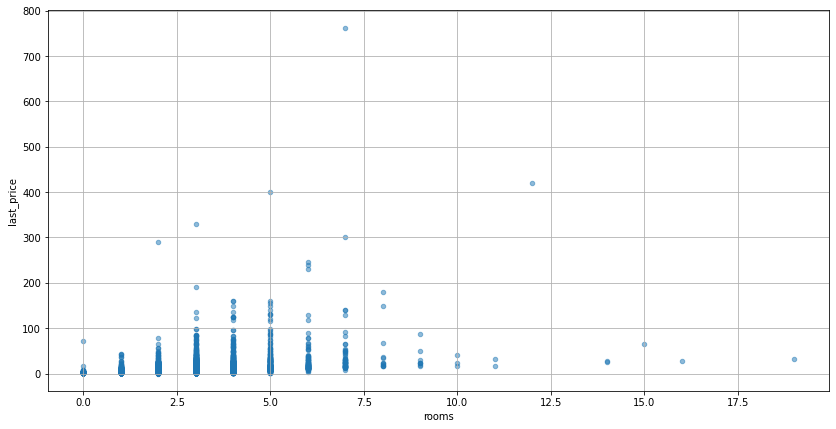

In [149]:
def corr1(column):
    print('Корелляция цены от',column , data['last_price'].corr(data[column]))
    data.plot(x=column, y='last_price', kind='scatter', grid=True, figsize=(14,7), alpha=0.5);

corr1('rooms')

Зависимость цены от кол-ва комнат слабо прослеживается. Она увеличивается, при возрастании комнат от 1 до 3. Очень много квартир от 1 до 6 комнат в диапазоне до 30 млн - это показывает что зависимость всетаки довольно слаба и уже в квартирах от 3 комнат уже отсутствует

* Зависимость Цена от Удалённости от центра

Корелляция цены от cityCenters_nearest -0.2056199151476516


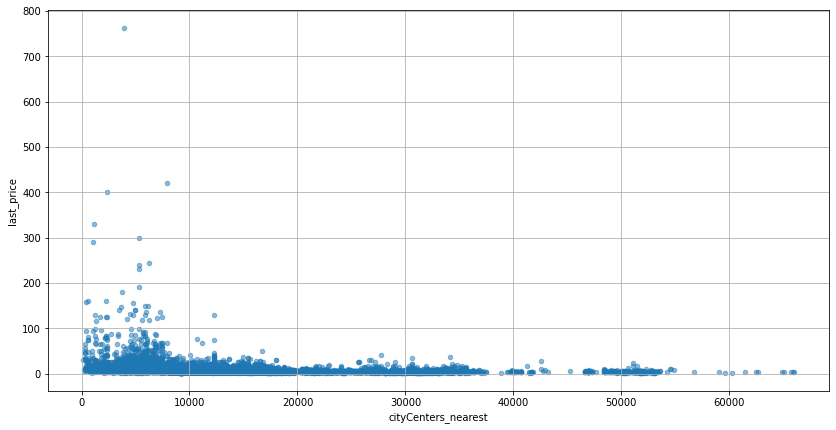

In [150]:
def corr1(column):
    print('Корелляция цены от',column , data['last_price'].corr(data[column]))
    data.plot(x=column, y='last_price', kind='scatter', grid=True, figsize=(14,7), alpha=0.5);

corr1('cityCenters_nearest')

Цена слабо зависит от расстояния до центра, причем количество более дорогих квартир возрастает при увеличении расстояния до 5-6км, а потом снижается. Надо отметить всплеск цен (до 5-7млн) и продаж на растоянии 45-55км, возможно там какой-то крупный населенный пункт(регион/область)

*  Зависимость цены от того, на каком этаже расположена квартира: первом, последнем или другом

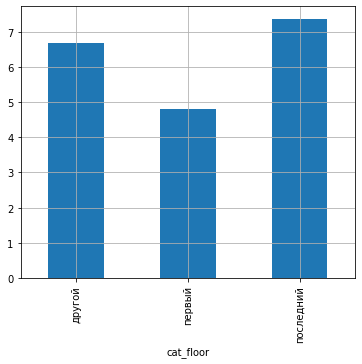

In [151]:
#Вычислим среднюю цену в каждой категории
cat_fl_mean = data.groupby('cat_floor')['last_price'].mean();
# cat_fl_mean.plot(x=0, y=1, kind='bar', grid=True, figsize=(10,5));
# plt.show()
cat_fl_mean.plot(x=cat_fl_mean.index, y=cat_fl_mean.values, kind='bar', grid=True, figsize=(6,5));

Гистограмма показывает - первый этаж самый не популярный, поэтому средняя цена ниже всех(чем меньше спрос, тем меньше цена). Более предпочтителен другой этах - не первый и не последний - на него цена выше.

* Зависимость от даты размещения: дня недели, месяца и года.

<AxesSubplot:xlabel='year_exp'>

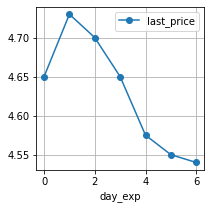

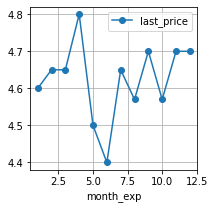

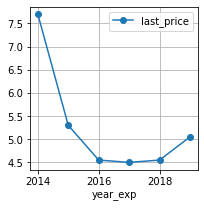

In [152]:
# Зависимость цены от дня недели
data.pivot_table(index='day_exp', values='last_price', aggfunc='median').plot(grid=True, style='o-', figsize=(3, 3))
# Зависимость цены от месяца размещения объявления
data.pivot_table(index='month_exp', values='last_price', aggfunc='median').plot(grid=True, style='o-', figsize=(3, 3))
# Зависимость цены от года размещения объявления
data.pivot_table(index='year_exp', values='last_price', aggfunc='median').plot(grid=True, style='o-', figsize=(3, 3))

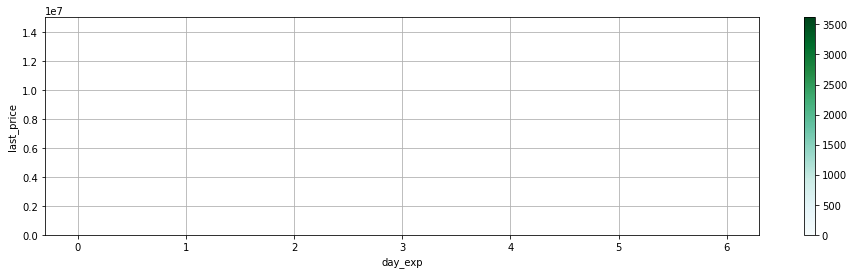

In [153]:
data.plot(x='day_exp', y='last_price', kind='hexbin', gridsize=50, sharex=False, grid=True, figsize=(16,4),ylim=(0,15000000));

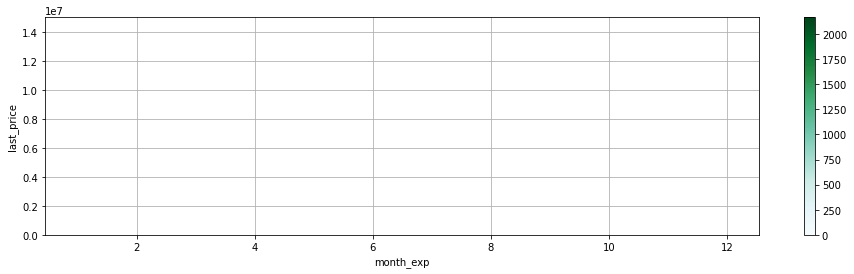

In [154]:
data.plot(x='month_exp', y='last_price', kind='hexbin', gridsize=50, sharex=False, grid=True, figsize=(16,4),ylim=(0,15000000));

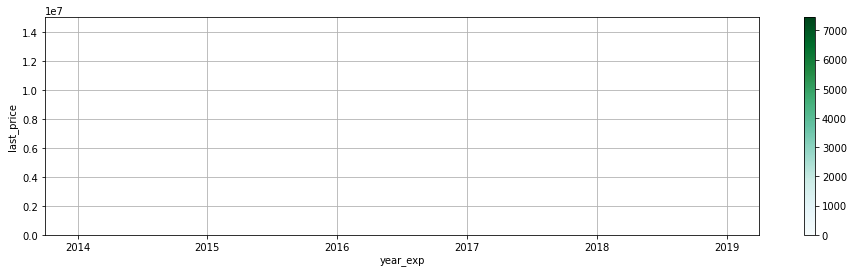

In [155]:
data.plot(x='year_exp', y='last_price', kind='hexbin', gridsize=50, sharex=False, grid=True, figsize=(16,4),ylim=(0,15000000));

Цена НЕ зависит от дня недели, месяца и года размещения объявления



_**Вывод:**_ Больше всего на стоимость квартиры влияет её площадь(прямопропорцианальная зависимость). Среднее влияние оказывает удаленность от центра(обратнопропорцианальная зависимость) и количество комнат (особенно хорошо видна прямопропорцианальная зависимость на отрезке 1-3 комнаты, все что выше уже не коррелирует). Также надо отметить, что есть зависимость от этажа - первый этаж мало кто любит и цена его существенно отличается от остальных; люди предпочитают не первый и не последний этаж - его цена выше(но на немного выше последнего). Дата же размещения не оказывает влияния на цену.

_**Посчитаем среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — постройте сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов. Выделите населённые пункты с самой высокой и низкой стоимостью квадратного метра**_

In [156]:
# --1способ--------------
loc10 = data.groupby('locality_name')['sq_metr_pr'].agg(['count', 'mean']).sort_values(by='count', ascending=False).head(10)
loc10.columns = ['flats', 'sq_metr_price']
loc10.reset_index(inplace=True)
# -------------------------


# ---2способ--------------
# loc10 = data.pivot_table(index = 'locality_name', values = 'sq_metr_pr', aggfunc=['count', 'mean'])
# loc10.columns = ['flats', 'sq_metr_price']
# loc10 = loc10.sort_values(by='flats', ascending=False).head(10)
# -------------------------

print(loc10)
print()
# print(loc10['sq_metr_price'].agg(['min', 'max']))
print('ВЫВОД:')
print('Населённый пункт, где cамая низкая стоимость жилья')
print(loc10.loc[loc10['sq_metr_price']==loc10['sq_metr_price'].min()])
print()
print('Населённый пункт, где cамая высокая стоимость жилья')
print(loc10.loc[loc10['sq_metr_price']==loc10['sq_metr_price'].max()])

       locality_name  flats  sq_metr_price
0    Санкт-Петербург  15681  114809.266054
1     поселок Мурино    552   85629.110507
2     поселок Шушары    438   78569.694064
3         Всеволожск    398   68654.007538
4             Пушкин    369  103125.373984
5            Колпино    338   75424.150888
6  поселок Парголово    327   90175.489297
7            Гатчина    307   68745.693811
8    деревня Кудрово    299   92473.086957
9             Выборг    237   58141.489451

ВЫВОД:
Населённый пункт, где cамая низкая стоимость жилья
  locality_name  flats  sq_metr_price
9        Выборг    237   58141.489451

Населённый пункт, где cамая высокая стоимость жилья
     locality_name  flats  sq_metr_price
0  Санкт-Петербург  15681  114809.266054





_**Ранее мы посчитали расстояние до центра в километрах. Теперь выделим квартиры в Санкт-Петербурге с помощью столбца *locality_name* и вычислим их среднюю стоимость на разном удалении от центра. Учтем каждый километр расстояния: узнаем среднюю цену квартир в одном километре от центра, в двух и так далее. Опишем, как стоимость объектов зависит от расстояния до центра города — построим график изменения средней цены для каждого километра от центра Петербурга.**_

In [157]:
# spb = data.loc[data['locality_name']=='Санкт-Петербург',['sq_metr_pr', 'cityCenters_nearest']].reset_index(drop=True) # Вариант №1
spb = data.loc[data['locality_name']=='Санкт-Петербург',['last_price', 'cityCenters_nearest']].reset_index(drop=True) # Вариант №2
spb['dist_center_km'] = round(spb['cityCenters_nearest']/1000).astype(int)
print(spb.sample(10))

       last_price  cityCenters_nearest  dist_center_km
10090       3.350              15598.0              16
8193        5.800               7211.0               7
3390       11.600               5223.0               5
12771       6.200               6303.0               6
3431        2.550               9620.0              10
12351       3.525              12012.0              12
3814        3.100              12038.0              12
14748       9.800              13936.0              14
3147        4.900              10337.0              10
2822        3.630              15664.0              16


In [158]:
# price_km_spb = spb.pivot_table(index='dist_center_km', values='sq_metr_pr', aggfunc='mean') # Вариант №1
price_km_spb = spb.pivot_table(index='dist_center_km', values='last_price', aggfunc='mean') # Вариант №2
price_km_spb.head(8)

,last_price
dist_center_km,
0,31.449116
1,21.158707
2,17.808293
3,11.113324
4,13.270610
5,14.417667
6,15.338418
7,14.775153


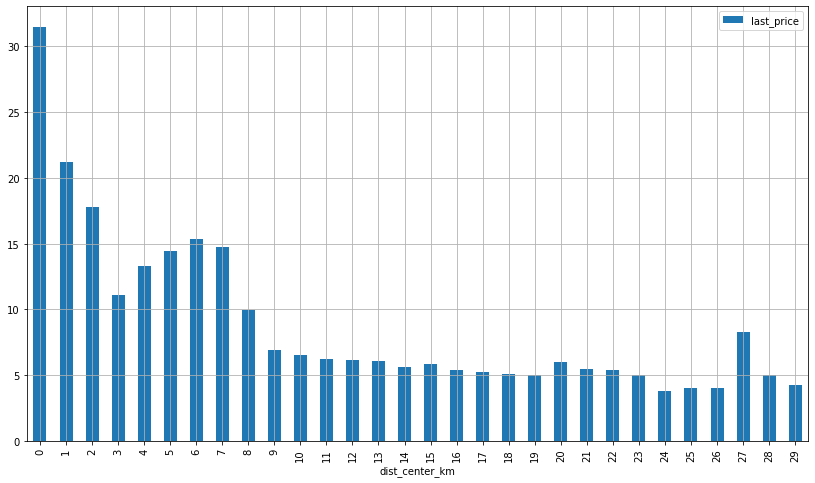

In [159]:

price_km_spb.plot(kind='bar', grid=True, figsize=(14,8));

Поскольку отчетливо видно, что яркий пик приходится на квартиры до 1 км, проверим еще раз есть ли "выбросы" в *last_price*

In [160]:
display(spb.query('cityCenters_nearest<1650').sort_values(by='last_price', ascending=False).head(25))

,last_price,cityCenters_nearest,dist_center_km
942,330.000000,1197.0,1
15121,289.238400,1073.0,1
12725,160.000000,555.0,1
10917,159.000000,436.0,0
9184,130.000000,1280.0,1
14530,115.490000,1328.0,1
3727,99.000000,1281.0,1
7502,95.000000,1032.0,1
305,95.000000,436.0,0
4267,82.000000,1280.0,1


Сильных выбросов нет, часть которая выше 100 млн была обрезана в предобработке столбца last_price, так же видно, что есть и дорогие квартиры

_**Вывод:** По гистограмме видно, что на расстоянии ДО 1 (это 0 км) км от центра цена очень высока (около 26,5 млн.р за квартиру) и сильно меняется уже после 1 км. от центра (16,3 млн.р за квартиру), все, что в радиусе до 1 км от центра - это и есть "самый центр".
Есть еще одна граница, она находится в районе 8 км от самого центра, после которой следует сильное падение цены (с 14млн до 9млн) и после начинает убывать постепенно. Это и есть центральная зона (в радиусе 8 км отцентра).
Будем называть обе территории вместе - Центр._

В задании не сказано какую цену использовать при расчетах (всей квартиры или квадратного метра(закомментирован)). Поэтому рассмотрены оба варианта, которые привели к одному и тому же выводу.

# Общий вывод

* Для анализа был дан ДатаСет с информацией по продаже квартир. Состоял из 22 колонок и 23699 строк. 7 колонок не пригодились *(total_images, open_plan, balcony, parks_around3000, parks_nearest, ponds_around3000, ponds_nearest).*

* В процессе предобработки было удалено 0,27% данных - вполне хорошо.
* столбец first_day_exposition приведен к типу datetime64
* В столбце ceiling_height заменили большую часть на медиану. Здесь были обнаружены ошибочно введенные значения, в которых справа присутствовал лищний ноль,- исправили
* В столбцах living_area и kitchen_area произведена взаимосвязанная заменя медианами. Так же учтены квартиры студии (их 149), - в строках где студии в столбце kitchen_area оставлено NaN.
* В числовых столбцах заменены типы на int, кроме столбцов с площадями(округлено до 0,1), и столбцов с расстояниями (оставили float - здесь мрого пропусков)
* в столбце days_exposition пропуски заполненны медианами в зависимости от населенного пункта
* Обрезаны сильные выбросы в столбцах где они имели место. Удалено 3 дубликата

    - В столбцах с расстояниями заменяли пропуски средними значениями по каждому населенному пункту (удалось заполнить совсем мало значений) и при обработке было выясненно , что полностью невозможно заполнить столбцы с расстояниями: airports_nearest, parks_nearest, ponds_nearest и особенно важный cityCenters_nearest. Единственная возможность заполнить пропуски в них - заполнить средней или медианой всего столбца - но в таком случае при решении задач дальнейшего анализа это сильно может исказать результаты! Поэтому при анализе, там где будет затронут столбец cityCenters_nearest, будем довольствоваться 18737 (-27%!) строками, где присутствуют значения в этом столбце.
    - В ДатаФрейм "matches_True" - сохранены строки в которых пропуски в расстояниях(Баг-Репорт) airports_nearest, parks_nearest, ponds_nearest и особенно важный cityCenters_nearest
    - Столбы days_exposition и 4 столбца с расстояниями заполнялись по одинаковому алгоритму - по соответствию - "расстояние-населенный пугкт".
    - По заданию было добавлено столбцы, в которых были подсчитаны дополнительные параметры:

* цена квадратного метра;
* день недели, месяц и год публикации объявления;
* этаж квартиры; 
* варианты — первый, последний, другой;
* соотношение жилой и общей площади, а также отношение площади кухни к общей.

_Был проведен анализ и сделаны выводы по заданым вопросам:_

1. Больше всего квартир с площадями 30-46 кв.м - это, похоже, самые популярные 1 и 2-х комнатные. Далее идут скорее всего 2 и 3 комнатные с площадью до 75 кв.м.

2. Сделан вывод, что больше всего квартир продаются по цене в диапазоне 1,8-7,5 млн.руб. Пик же продажи квартир идет в по цене около 3,8 мнн.

3. самые популярные квартиры - 1комнатная(чуть больше 8000) и 2комнатные(около 8000). 3комнатных тоже довольно много - чуть меньше 6000, ну а дальше кол-во сильно сокращаетя.

4. Больше всего квартир с высотой потолков 250 - 300 см, подавляющее большинство почти половина с высотой 265 см.

* Факторы больше всего влияющие на стоимость квартиры: Больше всего на стоимость квартиры влияет её площадь(прямопропорцианальная зависимость). Среднее влияние оказывает удаленность от центра(обратнопропорцианальная зависимость) и количество комнат (особенно хорошо видна прямопропорцианальная зависимость на отрезке 1-3 комнаты, все что выше уже не коррелирует). Также надо отметить, что есть зависимость от этажа - первый этаж мало кто любит и цена его существенно отличается от остальных; люди предпочитают не первый и не последний этаж - его цена выше(но на немного выше последнего).

* Подавляющее большинство квартир продается в Питере - 15712, а цена около 113500р/кв.м. Помимо Питера в Топ10 входят: поселок Мурино, поселок Шушары, Всеволожск, Пушкин, Колпино, поселок Парголово, Гатчина, деревня Кудрово, Выборг с ценами 58000 - 85500р/кв.м

* В ходе анализа квартир в центре Питера было выявлено - что на расстоянии ДО 1 (это 0 км) км от центра цена очень высока (около 26,5 млн.р за квартиру) и сильно меняется уже после 1 км. от центра (16,3 млн.р за квартиру), все, что в радиусе до 1 км от центра - это и есть "самый центр". Есть еще одна граница, она находится в районе 8 км от самого центра, после которой следует сильное падение цены (с 14млн до 9млн) и после начинает убывать постепенно. Это и есть центральная зона (в радиусе 8 км от центра). 

**Чек-лист готовности проекта**

- [x]  Файл с данными открыт.
- [x]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [x]  Найдены пропущенные значения.
- [x]  Пропущенные значения заполнены там, где это возможно.
- [x]  Объяснено, какие пропущенные значения обнаружены.
- [x]  В каждом столбце установлен корректный тип данных.
- [x]  Объяснено, в каких столбцах изменён тип данных и почему.
- [x]  Устранены неявные дубликаты в названиях населённых пунктов.
- [x]  Обработаны редкие и выбивающиеся значения (аномалии).
- [x]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [x]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [x]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [x]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [x]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [x]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [x]  На каждом этапе сделаны промежуточные выводы.
- [x]  В конце проекта сделан общий вывод.